<div style="position: relative; text-align: center; background: #000; padding: 20px 10px; border-radius: 15px; box-shadow: 0 10px 25px rgba(0,0,0,0.7); font-family: 'Segoe UI', sans-serif; color: white;">

  <img src="https://i.postimg.cc/90vL5cPP/Image.jpg" 
       alt="Title Image" 
       style="display: block; margin: 2px auto 5px auto; border-radius: 10px; box-shadow: 0 0 10px #666;">
  
  <span style="
  color: #B8860B;
  font-family: 'Times New Roman', Times, serif;
  font-weight: bold;
  padding-bottom: 2px;
">
  Samane Najarian
</span>

</div>

# 📊 Customer Behavior Analysis - E-commerce

## 📌 Project Overview

This project analyzes customer purchasing behavior using an e-commerce dataset.

The goal is to provide **data-driven insights** that help the company improve:
- 🎯 Marketing strategies
- 🤝 Customer retention
- 💰 Revenue growth
- 📈 Business decision-making

---

## ❓ Business Questions

This analysis aims to answer:

- 📊 What are the key business performance indicators?
- 🌍 Which city should be targeted for the next marketing campaign?
- ⭐ Who are the most valuable customers?
- ⚠️ Which customers are at risk of leaving?
- 🏷️ How do discount users differ from non-discount users?
- 👥 Can customers be grouped into meaningful segments?
- 📈 Does a small percentage of customers generate most of the revenue?

---

## 🗂️ Dataset

The dataset contains customer and transaction information used to analyze purchasing patterns and customer behavior.

Main information includes:

- 👤 Customer information
- 🛒 Transaction details
- 💳 Purchase behavior
- 📍 Customer location
- 🏷️ Discount usage

---

In [1]:
# Import Libraies
import numpy as np
import pandas as pd
#!pip install ydata-profiling
from ydata_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt
!pip install jdatetime
import jdatetime
import datetime
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import KNNImputer
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.tree import DecisionTreeClassifier, export_text
import plotly.graph_objects as go
from scipy.stats import norm
from sklearn.model_selection import train_test_split

# Modelling
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import _tree

# Validation
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import f1_score, make_scorer
#pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.warn("this will not show")

# Figure&Display options
plt.rcParams["figure.figsize"] = (16, 9)
pd.set_option('max_colwidth',200)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


#!pip install ydata_profiling
# !pip install -U pandas-profiling --user
#import pandas_profiling
#from pandas_profiling.report.presentation.flavours.html.templates import create_html_assets

/tmp/ipykernel_58/309665374.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df_customer = pd.read_excel("/kaggle/input/datasets/samanenajarian/dataset/First Dataset.xlsx")
df_customer.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.00,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.00,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.00,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.00,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.00,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [3]:
df_customer.shape

(61, 17)

In [4]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         61 non-null     int64  
 1   first_name          61 non-null     object 
 2   gender              61 non-null     object 
 3   age                 60 non-null     float64
 4   city                61 non-null     object 
 5   province            61 non-null     object 
 6   signup_date         61 non-null     object 
 7   membership_tier     61 non-null     object 
 8   purchase_count      61 non-null     int64  
 9   avg_order_value     61 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  61 non-null     int64  
 12  payment_method      61 non-null     object 
 13  device              61 non-null     object 
 14  discount_used       61 non-null     object 
 15  returned_items      61 non-null     int64  
 16  satisfacti

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Data Preprocessing
</div>

In [5]:
#profile = ProfileReport(df_customer, title="Customer Satisfaction data EDA")
#profile

#profile.to_file("Customer Satisfaction data EDA.html")

In [6]:
Filtered_df = df_customer.copy()

In [7]:
# Convert signup date to datetime format, extract signup year and month,
# then remove the original date column after feature extraction.

Filtered_df['signup_date'] = pd.to_datetime(
    Filtered_df['signup_date']
)
Filtered_df['signup_year'] = Filtered_df['signup_date'].dt.year

Filtered_df['signup_month'] = Filtered_df['signup_date'].dt.month

Filtered_df = Filtered_df.drop(
    'signup_date',
    axis=1
)

In [7]:
# Identify duplicate records and remove duplicated rows while keeping the first occurrence.

duplicates = Filtered_df[Filtered_df.duplicated(keep=False)]
Filtered_df = Filtered_df.drop_duplicates(keep='first')

In [8]:
# Remove unnecessary columns and set customer_id as the dataframe index for easier identification.

Filtered_df.drop(columns=['first_name'], inplace=True )
Filtered_df.set_index('customer_id', inplace=True)
Filtered_df.head()

,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
customer_id,,,,,,,,,,,,,,,
1001,F,19.00,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1002,M,53.00,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
1003,F,31.00,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
1004,F,58.00,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
1005,M,28.00,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [9]:
# Separate the target variable from the features, then split the data into training and testing sets.

y = Filtered_df.iloc[:,-3]
X = Filtered_df.drop(Filtered_df.columns[-3],axis=1)
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=880)
print("X_train:",X_train.shape,"\n" "y_train:", y_train.shape,"\n" "X_test:", X_test.shape,"\n" "y_test:", y_test.shape)

X_train: (48, 14) 
y_train: (48,) 
X_test: (12, 14) 
y_test: (12,)


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Handling Outliers
</div>

In [15]:
X_train_Cleaning = X_train.copy()
y_train_Cleaning = y_train.copy()

In [16]:
# Identify categorical and continuous features

columns = X_train.columns

categorical_indices = [i for i , col in enumerate(X_train.columns) if X_train[col].dtype=='object']

categorical_fields = [columns[i] for i in categorical_indices]

continuous_fields = [j for j in columns if j not in categorical_fields]

continuous_df = X_train[continuous_fields]

In [17]:
# Detect outliers in continuous features using the IQR method.
# Calculate the number and percentage of outliers for each feature.

Q1 = continuous_df.quantile(0.25)
Q3 = continuous_df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (continuous_df < lower) | (continuous_df > upper)

total_outliers = outliers.sum().sum()
total_values = continuous_df.size

percentage = (total_outliers / total_values) * 100

outlier_table = pd.DataFrame({
    "Feature": continuous_df.columns,
    "Outlier Count": outliers.sum().values,
    "Outlier Percentage (%)": (outliers.mean() * 100).round(2).values
})

outlier_table

,Feature,Outlier Count,Outlier Percentage (%)
0,age,0,0.00
1,purchase_count,0,0.00
2,avg_order_value,0,0.00
3,total_spending,5,10.42
4,last_purchase_days,0,0.00
5,returned_items,0,0.00
6,satisfaction_score,0,0.00


In [18]:
# Select and display rows that contain at least one outlier in the continuous features.

rows_with_outliers = continuous_df.loc[outliers.any(axis=1)]
rows_with_outliers

,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
customer_id,,,,,,,
1030,60.00,26,156.89,25000.00,340,4,4
1044,64.00,33,434.98,14354.34,165,7,2
1009,61.00,34,341.63,11615.42,232,8,2
1057,58.00,31,436.54,13532.74,82,4,4
1059,57.00,31,287.05,8898.55,224,0,5


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Outlier Handling Insight</h3>

<p>
Outliers were identified in continuous features using the <b>IQR method</b>. 
All detected outliers were related to the <b>total spending</b> feature. 
Since higher spending values can represent genuine customer purchasing behavior, 
these observations were considered valid rather than errors.
</p>

<p>
Additionally, the number of outliers was relatively small; therefore, they were 
<b>retained</b> to preserve valuable customer information and avoid losing meaningful 
patterns for further analysis.
</p>

</div>

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Handling Missing Values
</div>

In [19]:
# Combine the cleaned training features with the target variable into a single dataframe.

Cleaning_train = pd.concat([X_train_Cleaning, y_train_Cleaning], axis=1)
Cleaning_train.head()

,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,returned_items,satisfaction_score,discount_used
customer_id,,,,,,,,,,,,,,,
1026,M,19.00,Ahvaz,Khuzestan,2022-05-06,Bronze,11,335.41,3689.51,195,Card,iPhone,3,4,Yes
1058,F,47.00,Tehran,Tehran,2024-09-27,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,0,2,No
1040,F,65.00,Tehran,Tehran,2021-11-02,Bronze,34,37.66,NaN,126,Card,Android,3,2,Yes
1030,M,60.00,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.00,340,Cash,Web,4,4,Yes
1008,F,23.00,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,8,1,No


In [20]:
Cleaning_train.shape

(48, 15)

In [21]:
Cleaning_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 1026 to 1013
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              48 non-null     object 
 1   age                 47 non-null     float64
 2   city                48 non-null     object 
 3   province            48 non-null     object 
 4   signup_date         48 non-null     object 
 5   membership_tier     48 non-null     object 
 6   purchase_count      48 non-null     int64  
 7   avg_order_value     48 non-null     float64
 8   total_spending      47 non-null     float64
 9   last_purchase_days  48 non-null     int64  
 10  payment_method      48 non-null     object 
 11  device              48 non-null     object 
 12  returned_items      48 non-null     int64  
 13  satisfaction_score  48 non-null     int64  
 14  discount_used       48 non-null     object 
dtypes: float64(3), int64(4), object(8)
memory usage: 6.0+ KB


In [22]:
# Generate a missing values report showing the count and percentage of missing data for each column.

missing_values_report = pd.DataFrame({
    'Column': Cleaning_train.columns,
    'Missing Values': Cleaning_train.isnull().sum().values,
    'Percentage Missing': Cleaning_train.isnull().mean().values * 100
})

print("Missing Values Report:")
missing_values_report

Missing Values Report:


,Column,Missing Values,Percentage Missing
0,gender,0,0.00
1,age,1,2.08
2,city,0,0.00
3,province,0,0.00
4,signup_date,0,0.00
5,membership_tier,0,0.00
6,purchase_count,0,0.00
7,avg_order_value,0,0.00
8,total_spending,1,2.08
9,last_purchase_days,0,0.00


In [23]:
# Select and display rows that contain at least one missing value in the dataset.

rows_with_missing = Cleaning_train[Cleaning_train.isna().any(axis=1)]
rows_with_missing

,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,returned_items,satisfaction_score,discount_used
customer_id,,,,,,,,,,,,,,,
1040,F,65.00,Tehran,Tehran,2021-11-02,Bronze,34,37.66,NaN,126,Card,Android,3,2,Yes
1020,M,NaN,Isfahan,Isfahan,2024-06-25,Bronze,16,187.17,2994.72,4,Cash,Web,1,5,Yes


In [24]:
# Create a copy of the dataset and handle missing values in numerical features using mean imputation.

Cleaning_train_missing_fix = Cleaning_train.copy()

missing_vars = ['age','total_spending']
imputer = SimpleImputer(strategy='mean') 
                                                     

Cleaning_train_missing_fix[missing_vars] = imputer.fit_transform(Cleaning_train_missing_fix[missing_vars])

print("DataFrame after Imputation:")
Cleaning_train_missing_fix

Cleaning_train_missing_fix.info()

DataFrame after Imputation:
<class 'pandas.core.frame.DataFrame'>
Index: 48 entries, 1026 to 1013
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              48 non-null     object 
 1   age                 48 non-null     float64
 2   city                48 non-null     object 
 3   province            48 non-null     object 
 4   signup_date         48 non-null     object 
 5   membership_tier     48 non-null     object 
 6   purchase_count      48 non-null     int64  
 7   avg_order_value     48 non-null     float64
 8   total_spending      48 non-null     float64
 9   last_purchase_days  48 non-null     int64  
 10  payment_method      48 non-null     object 
 11  device              48 non-null     object 
 12  returned_items      48 non-null     int64  
 13  satisfaction_score  48 non-null     int64  
 14  discount_used       48 non-null     object 
dtypes: float64(3), int64(4), object

In [25]:
# Save the cleaned dataset with imputed missing values as a CSV file.

Cleaning_train_missing_fix.to_csv('/kaggle/working/Final_data.csv')

## 🔍 Analysis Performed

### 1️⃣ 📊 Business KPIs

Calculated key performance indicators:

- 💰 Total revenue
- 🛍️ Number of orders
- 📦 Average order value

---



In [ ]:
# Load the final cleaned dataset

Final_data = pd.read_csv('/kaggle/working/Final_data.csv')
Final_data.head()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Business Performance KPIs</h3>

<p>
Key Performance Indicators (<b>KPIs</b>) provide a concise overview of business performance 
and help evaluate overall customer purchasing behavior. In this analysis, KPIs are 
calculated to understand the company's sales performance and identify important 
business trends.
</p>

<p>
The selected metrics include <b>Total Revenue</b>, <b>Total Orders</b>, and 
<b>Average Order Value</b>. These indicators help measure the total income generated, 
customer purchase activity, and the average amount spent per order.
</p>

<p>
By analyzing these KPIs, businesses can better understand customer value, evaluate 
current performance, and make more informed decisions regarding marketing strategies 
and customer engagement.
</p>

</div>

In [37]:
# Calculate key business metrics (KPIs) including total revenue, total orders, and average order value.
# Create a summary dataframe to display the overall business performance indicators.

total_revenue = Final_data['total_spending'].sum()

total_orders = Final_data['purchase_count'].sum()

average_order_value = Final_data['avg_order_value'].mean()


kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Average Order Value'
    ],
    'Value': [
        total_revenue,
        total_orders,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,174622.67
1,Total Orders,828.00
2,Average Order Value,204.22


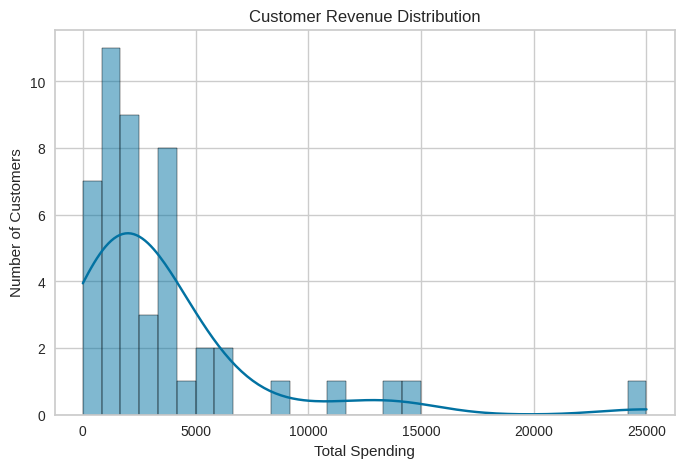

In [38]:
# Visualize the distribution of customer revenue using a histogram with a KDE curve.
# This helps identify spending patterns and the spread of customer value.

plt.figure(figsize=(8,5))

sns.histplot(
    Final_data['total_spending'],
    bins=30,
    kde=True
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

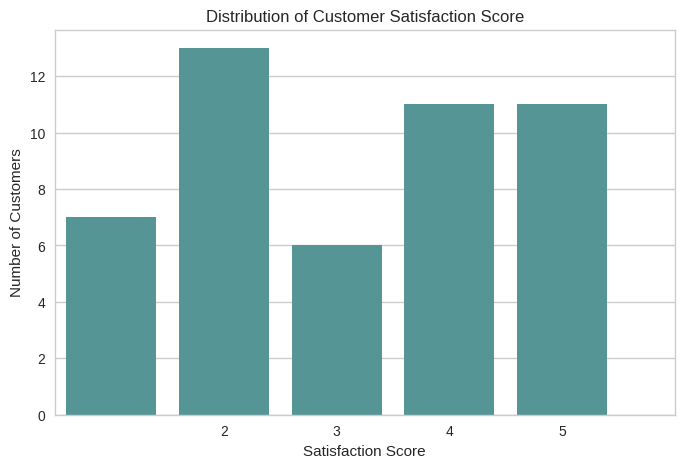

In [125]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=Final_data,
    x='satisfaction_score',
    color='#4C9F9F'
)

plt.title("Distribution of Customer Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.xticks(sorted(Final_data['satisfaction_score'].unique()))

plt.show()

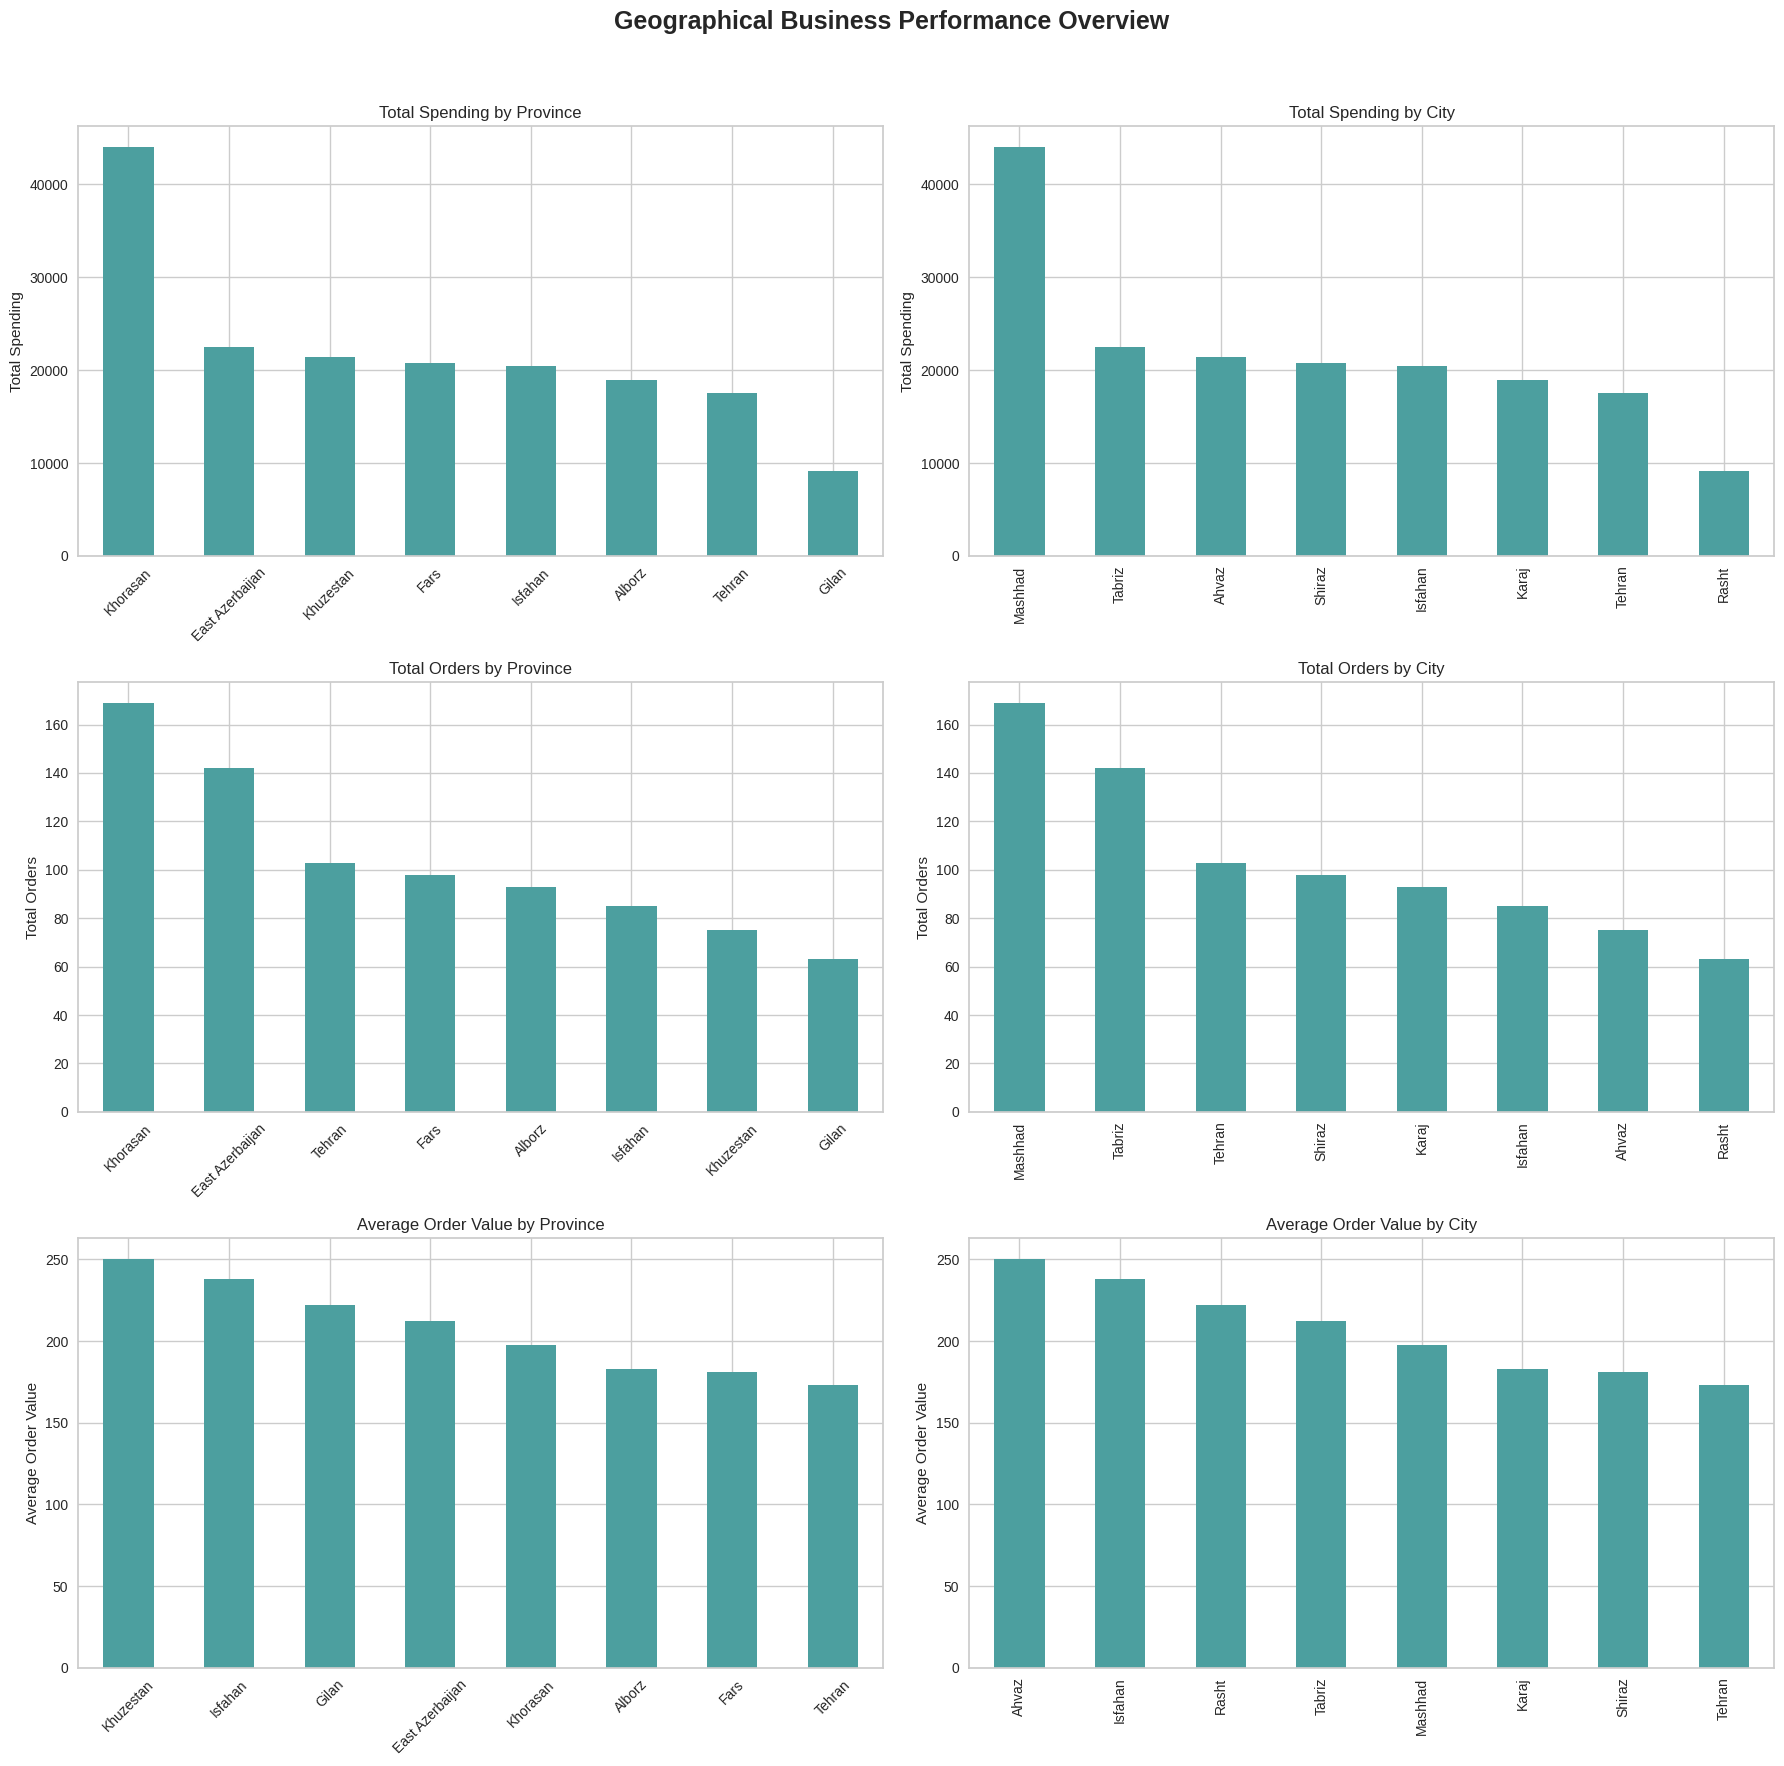

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

color = '#4C9F9F'

# 1. Total Spending by Province
province_spending = Final_data.groupby('province')['total_spending'].sum().sort_values(ascending=False)

province_spending.plot(kind='bar', ax=axes[0,0], color=color)
axes[0,0].set_title("Total Spending by Province")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Total Spending")
axes[0,0].tick_params(axis='x', rotation=45)


# 2. Total Spending by City
city_spending = Final_data.groupby('city')['total_spending'].sum().sort_values(ascending=False)

city_spending.plot(kind='bar', ax=axes[0,1], color=color)
axes[0,1].set_title("Total Spending by City")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Total Spending")
axes[0,1].tick_params(axis='x', rotation=90)


# 3. Total Orders by Province
province_orders = Final_data.groupby('province')['purchase_count'].sum().sort_values(ascending=False)

province_orders.plot(kind='bar', ax=axes[1,0], color=color)
axes[1,0].set_title("Total Orders by Province")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Total Orders")
axes[1,0].tick_params(axis='x', rotation=45)


# 4. Total Orders by City
city_orders = Final_data.groupby('city')['purchase_count'].sum().sort_values(ascending=False)

city_orders.plot(kind='bar', ax=axes[1,1], color=color)
axes[1,1].set_title("Total Orders by City")
axes[1,1].set_xlabel("")
axes[1,1].set_ylabel("Total Orders")
axes[1,1].tick_params(axis='x', rotation=90)


# 5. Average Order Value by Province
province_aov = Final_data.groupby('province')['avg_order_value'].mean().sort_values(ascending=False)

province_aov.plot(kind='bar', ax=axes[2,0], color=color)
axes[2,0].set_title("Average Order Value by Province")
axes[2,0].set_xlabel("")
axes[2,0].set_ylabel("Average Order Value")
axes[2,0].tick_params(axis='x', rotation=45)


# 6. Average Order Value by City
city_aov = Final_data.groupby('city')['avg_order_value'].mean().sort_values(ascending=False)

city_aov.plot(kind='bar', ax=axes[2,1], color=color)
axes[2,1].set_title("Average Order Value by City")
axes[2,1].set_xlabel("")
axes[2,1].set_ylabel("Average Order Value")
axes[2,1].tick_params(axis='x', rotation=90)


fig.suptitle("Geographical Business Performance Overview",
             fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3️⃣ ⭐ Customer Value Analysis

Identified the **Top 10 most valuable customers** based on purchasing behavior to support loyalty campaign decisions.

---

In [40]:
# Identify the top 10 customers based on their total spending to support customer value analysis and loyalty targeting.

top_10_customers = Final_data.sort_values(
    by='total_spending',
    ascending=False
).head(10)

top_10_customers

,customer_id,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,returned_items,satisfaction_score,discount_used
3,1030,M,60.00,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.00,340,Cash,Web,4,4,Yes
14,1044,M,64.00,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,7,2,No
34,1057,M,58.00,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,4,4,No
16,1009,M,61.00,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,8,2,No
44,1059,F,57.00,Isfahan,Isfahan,2023-09-05,Gold,31,287.05,8898.55,224,Online Wallet,iPhone,0,5,Yes
20,1004,F,58.00,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,4,4,No
19,1035,M,58.00,Tabriz,East Azerbaijan,2022-05-15,Bronze,17,348.13,5918.21,365,Cash,Android,5,3,No
24,1053,M,32.00,Tehran,Tehran,2021-11-08,Gold,18,322.53,5805.54,320,Online Wallet,Web,6,1,Yes
46,1033,F,63.00,Tabriz,East Azerbaijan,2021-02-25,VIP,24,230.05,5521.20,112,Card,Web,0,5,No
33,1032,F,23.00,Isfahan,Isfahan,2022-01-02,Silver,15,307.67,4615.05,243,Online Wallet,Android,6,5,No


### 4️⃣ ⚠️ Churn Risk Analysis

Identified customers with reduced purchasing activity who may require retention strategies.

---

In [41]:
# Identify customers at risk of churn based on the highest values of days since their last purchase.
# Customers with longer inactivity periods are considered potential churn risks.

churn_threshold = Final_data['last_purchase_days'].quantile(0.75)

at_risk_customers = Final_data[
    Final_data['last_purchase_days'] >= churn_threshold
].sort_values(
    by='last_purchase_days',
    ascending=False
)

at_risk_customers.head(10)

,customer_id,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,returned_items,satisfaction_score,discount_used
19,1035,M,58.00,Tabriz,East Azerbaijan,2022-05-15,Bronze,17,348.13,5918.21,365,Cash,Android,5,3,No
3,1030,M,60.00,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.00,340,Cash,Web,4,4,Yes
1,1058,F,47.00,Tehran,Tehran,2024-09-27,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,0,2,No
32,1016,F,45.00,Shiraz,Fars,2024-09-04,Bronze,11,136.17,1497.87,333,Online Wallet,Android,3,2,Yes
24,1053,M,32.00,Tehran,Tehran,2021-11-08,Gold,18,322.53,5805.54,320,Online Wallet,Web,6,1,Yes
28,1029,F,34.00,Tabriz,East Azerbaijan,2023-07-03,Gold,2,323.32,646.64,319,Cash,Web,4,5,Yes
18,1019,M,22.00,Shiraz,Fars,2021-10-08,Bronze,4,308.72,1234.88,317,Card,iPhone,4,2,No
7,1025,F,41.00,Mashhad,Khorasan,2021-06-25,VIP,2,406.03,812.06,317,Online Wallet,Android,2,2,Yes
15,1007,F,43.00,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,2,5,Yes
43,1024,F,53.00,Ahvaz,Khuzestan,2025-01-27,Gold,0,63.67,0.00,298,Online Wallet,Android,2,1,No


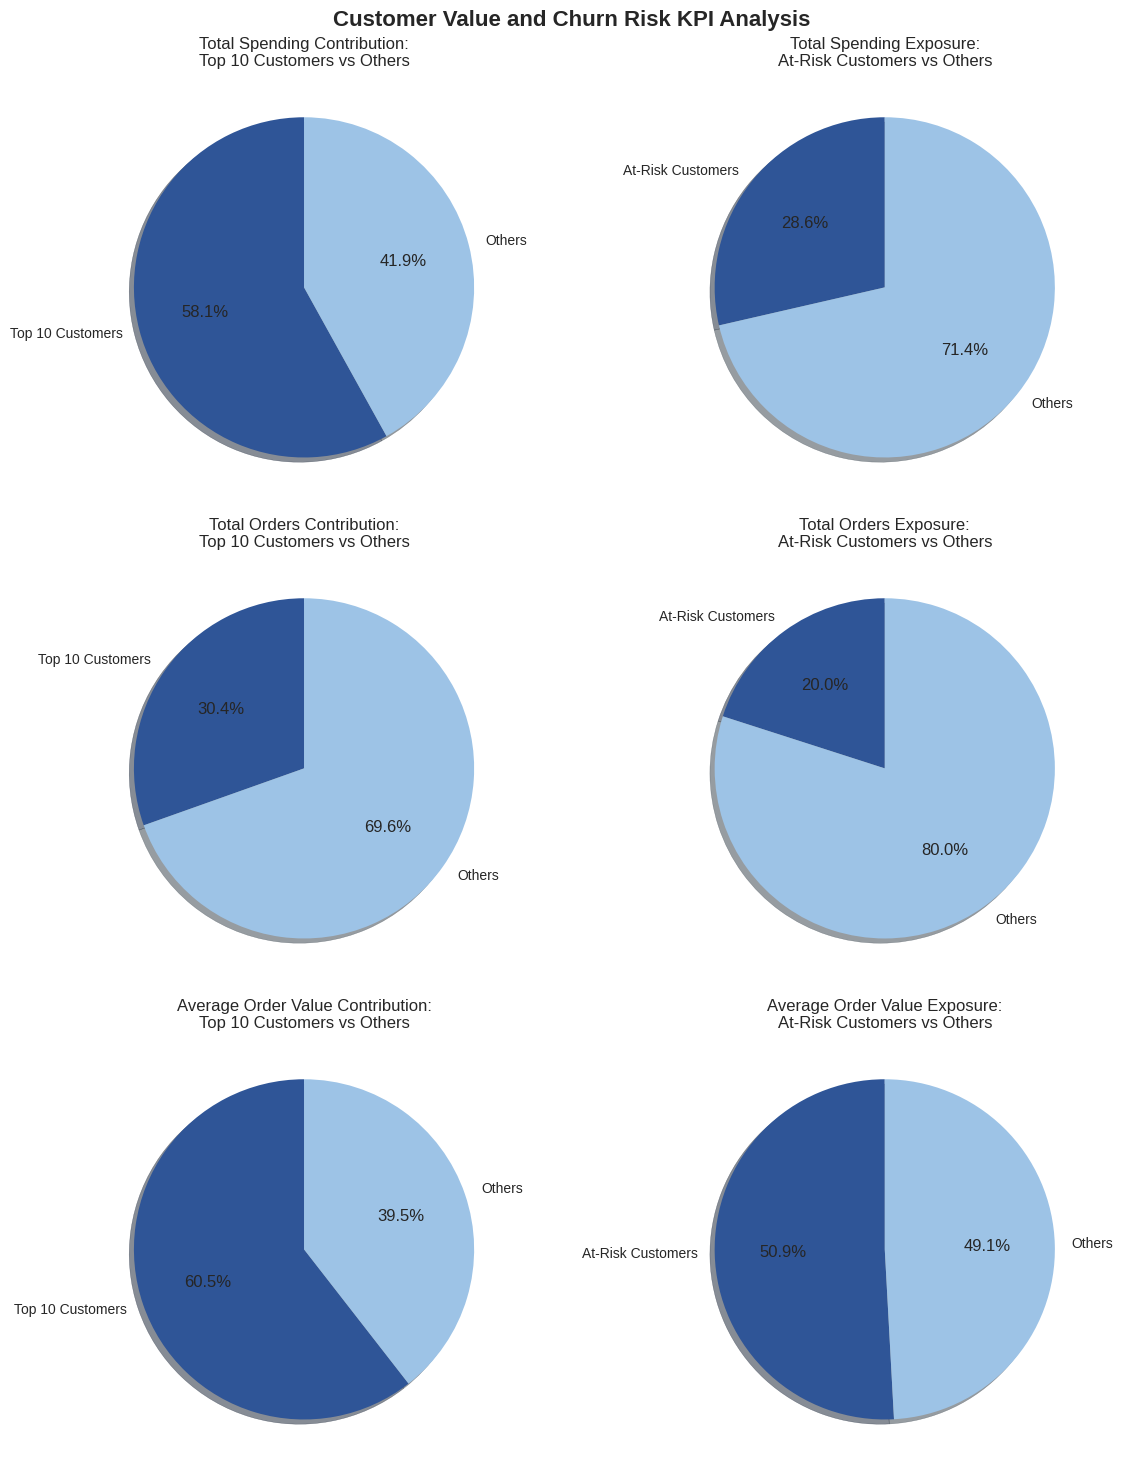

In [46]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

kpis = [
    ('total_spending', 'Total Spending'),
    ('purchase_count', 'Total Orders'),
    ('avg_order_value', 'Average Order Value')
]


for i, (kpi, title) in enumerate(kpis):

    # --- Top 10 Customers Contribution ---
    
    top10_value = top_10_customers[kpi].sum() if kpi != 'avg_order_value' else top_10_customers[kpi].mean()
    
    others_value = (
        Final_data[kpi].sum() - top10_value
        if kpi != 'avg_order_value'
        else Final_data[kpi].mean()
    )

    top10_colors = ['#2F5597', '#9DC3E6']  # dark blue, light blue
    risk_colors = ['#2F5597', '#9DC3E6']

    top10_data = pd.Series({
        'Top 10 Customers': top10_value,
        'Others': others_value
    })

    axes[i, 0].pie(
    top10_data,
    labels=top10_data.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=top10_colors
)
    
    

    axes[i, 0].set_title(
        f"{title} Contribution:\nTop 10 Customers vs Others"
    )


    # --- At-Risk Customers Contribution ---

    risk_value = at_risk_customers[kpi].sum() if kpi != 'avg_order_value' else at_risk_customers[kpi].mean()

    active_value = (
        Final_data[kpi].sum() - risk_value
        if kpi != 'avg_order_value'
        else Final_data[kpi].mean()
    )

    risk_data = pd.Series({
        'At-Risk Customers': risk_value,
        'Others': active_value
    })
    
    axes[i, 1].pie(
    risk_data,
    labels=risk_data.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    colors=risk_colors
)

  
    axes[i, 1].set_title(
        f"{title} Exposure:\nAt-Risk Customers vs Others"
    )


plt.suptitle(
    "Customer Value and Churn Risk KPI Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 5️⃣ 🏷️ Discount Analysis

Compared purchasing behavior between:

- Customers who used discounts
- Customers who did not use discounts

---

In [120]:
# Compare customer purchasing behavior based on discount usage.
# Calculate the average total spending, purchase frequency,
#and average order value for customers who used discounts versus those who did not.

discount_comparison = Final_data.groupby('discount_used').agg({
    'total_spending': 'mean',
    'purchase_count': 'mean',
    'avg_order_value': 'mean'
}).reset_index()

discount_comparison

,discount_used,total_spending,purchase_count,avg_order_value
0,No,3665.45,17.04,215.15
1,Yes,3605.50,17.50,191.31


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Discount Usage Analysis Insight</h3>

<p>
The impact of discount usage was evaluated by comparing key customer behavior metrics, 
including <b>total spending</b>, <b>purchase frequency</b>, and 
<b>average order value</b> between customers who used discounts and those who did not.
</p>

<p>
This analysis helps determine whether discounts effectively encourage customer 
engagement and increase purchasing activity. By comparing these KPIs, we can assess 
whether discount strategies contribute to higher customer value or mainly reduce 
revenue without generating significant additional purchases.
</p>

<p>
The results provide valuable insights for optimizing promotional strategies and 
help identify whether discounts should be used as a customer acquisition tool, 
a retention strategy, or applied more selectively to maximize business value.
</p>

</div>

### 6️⃣ 📈 Pareto Analysis

Analyzed revenue distribution to determine whether a small percentage of customers generates most of the company's revenue.

In [106]:
# Select customer ID and revenue-related metric
pareto_data = Final_data[['customer_id', 'total_spending']].copy()

# Rank customers based on total spending
pareto_data = pareto_data.sort_values(
    by='total_spending',
    ascending=False
).reset_index(drop=True)

pareto_data.head()

,customer_id,total_spending
0,1030,25000.00
1,1044,14354.34
2,1057,13532.74
3,1009,11615.42
4,1059,8898.55


In [111]:
# Calculate total revenue across all customers
total_revenue = pareto_data['total_spending'].sum()

# Calculate each customer's percentage contribution to total revenue
pareto_data['revenue_percentage'] = (
    pareto_data['total_spending'] / total_revenue
) * 100

# Calculate cumulative revenue contribution for Pareto analysis
pareto_data['cumulative_percentage'] = (
    pareto_data['revenue_percentage'].cumsum()
)

pareto_data.head()

,customer_id,total_spending,revenue_percentage,cumulative_percentage
0,1030,25000.00,14.32,14.32
1,1044,14354.34,8.22,22.54
2,1057,13532.74,7.75,30.29
3,1009,11615.42,6.65,36.94
4,1059,8898.55,5.10,42.03


In [112]:
# Calculate total revenue generated by all customers
total_revenue = pareto_data['total_spending'].sum()

# Calculate each customer's contribution to total revenue (%)
pareto_data['revenue_percentage'] = (
    pareto_data['total_spending'] / total_revenue
) * 100

# Calculate cumulative revenue contribution (%) for Pareto analysis
pareto_data['cumulative_percentage'] = (
    pareto_data['revenue_percentage'].cumsum()
)

pareto_data.head()

,customer_id,total_spending,revenue_percentage,cumulative_percentage
0,1030,25000.00,14.32,14.32
1,1044,14354.34,8.22,22.54
2,1057,13532.74,7.75,30.29
3,1009,11615.42,6.65,36.94
4,1059,8898.55,5.10,42.03


In [117]:
# Find the first customer reaching or exceeding 80% cumulative revenue
customers_80 = pareto_data[
    pareto_data['cumulative_percentage'] >= 80
].index[0]

# Calculate percentage of customers contributing to 80% of revenue
percentage_customers = (
    (customers_80 + 1) / len(pareto_data)
) * 100

# Display Pareto insight
print(
    f"{percentage_customers:.2f}% of customers generate approximately 80% of revenue")

43.75% of customers generate approximately 80% of revenue


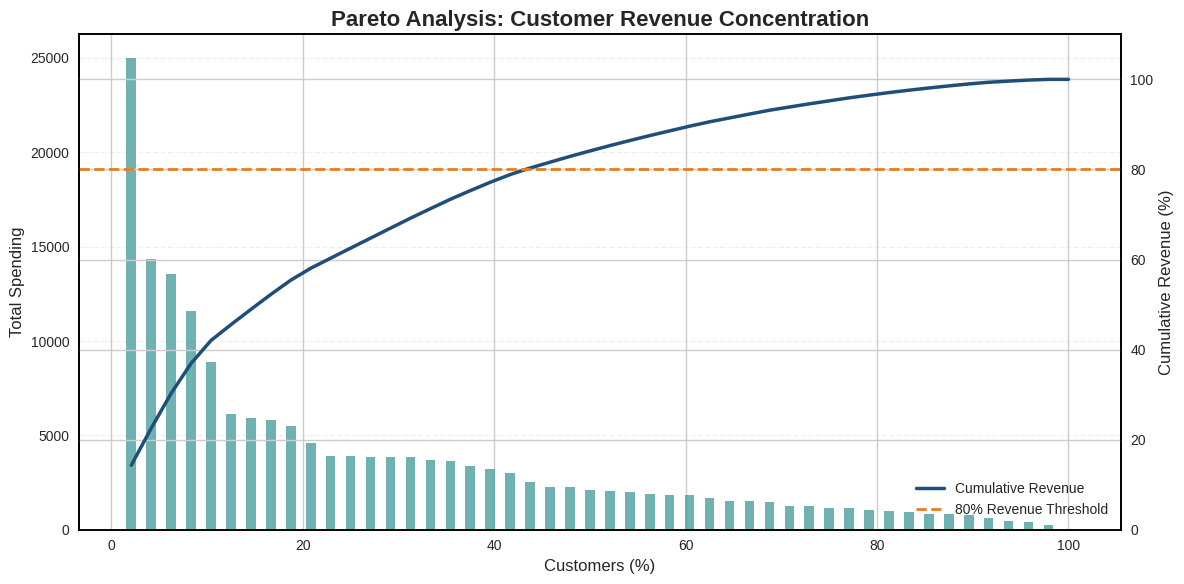

In [119]:
import matplotlib.pyplot as plt

# Calculate cumulative percentage of customers
pareto_data['customer_percentage'] = (
    (pareto_data.index + 1) / len(pareto_data)
) * 100


fig, ax1 = plt.subplots(figsize=(12, 6))

# Revenue contribution bars
ax1.bar(
    pareto_data['customer_percentage'],
    pareto_data['total_spending'],
    color='#4C9F9F',
    alpha=0.8,
    width=1
)

ax1.set_xlabel(
    "Customers (%)",
    fontsize=12
)

ax1.set_ylabel(
    "Total Spending",
    fontsize=12
)


# Cumulative revenue line
ax2 = ax1.twinx()

ax2.plot(
    pareto_data['customer_percentage'],
    pareto_data['cumulative_percentage'],
    color='#1F4E79',
    linewidth=2.5,
    label='Cumulative Revenue'
)


# 80% revenue threshold
ax2.axhline(
    y=80,
    color='#E67E22',
    linestyle='--',
    linewidth=2,
    label='80% Revenue Threshold'
)


ax2.set_ylabel(
    "Cumulative Revenue (%)",
    fontsize=12
)

ax2.set_ylim(0, 110)


# Title
plt.title(
    "Pareto Analysis: Customer Revenue Concentration",
    fontsize=16,
    fontweight='bold'
)


# Add black axis lines
for spine in ax1.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

for spine in ax2.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)


ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


ax2.legend(
    loc='lower right',
    shadow=True
)


plt.tight_layout()
plt.show()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Pareto Analysis Insight</h3>

<p>
The Pareto analysis shows that revenue is concentrated among a relatively small group of customers. 
Approximately 43.75% of customers generate 80% of total revenue, indicating that a limited number of high-value customers contribute significantly to business performance.
</p>

<p>
These customers should be prioritized through retention strategies, loyalty programs, and personalized offers to maintain their contribution and maximize customer lifetime value.
</p>

</div>

### 2️⃣ 👥 Customer Segmentation

 Customers were segmented using **RFM Analysis**:

 - 🔄 **Recency:** How recently customers purchased
 - 🔁 **Frequency:** How often customers purchased
 - 💵 **Monetary:** How much customers spent

 K-Means clustering was applied to identify meaningful customer groups.

---


In [53]:
 Create a customer information dataset by removing RFM-related behavioral features.
 Keep only customer profile attributes for further demographic and segmentation analysis.

customer_information = Final_data.drop(
    ['purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days'],
    axis=1
)
customer_information.set_index('customer_id', inplace=True)
customer_information.shape

(48, 11)

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    RFM Methodology
</div>

In [54]:
# Create the RFM dataset by extracting Recency (R), Frequency (F), and Monetary (M) values for each customer.

RFM = pd.DataFrame({
    'customer_id': Final_data['customer_id'],
    'R':Final_data['last_purchase_days'],
    'F':Final_data['purchase_count'],
    'M':Final_data['total_spending'],
})
RFM.set_index('customer_id', inplace=True)
RFM.head()

,R,F,M
customer_id,,,
1026,195,11,3689.51
1058,336,5,759.05
1040,126,34,3637.97
1030,340,26,25000.00
1008,195,3,1168.74


In [55]:
#profile_RFM = ProfileReport(RFM, title="RFM data EDA", type_schema = {"Ed": "categorical", "Default": "categorical"})

#profile_RFM.to_file("RFM_dataset_profile_report.html")

---

## 📈 Exploratory Data Analysis (EDA) on Aggregated RFM Data

After aggregating customer-level data, exploratory data analysis (EDA) was performed to evaluate data quality and understand the distribution of the main RFM metrics.

The distributions of **Recency (R)**, **Frequency (F)**, **Monetary (M)**, were analyzed to identify customer behavior patterns, detect potential outliers, and prepare the features for customer segmentation.

---

## 🎛️ RFM Categorization and Scoring

To transform continuous RFM values into meaningful customer behavior scores, each metric was categorized into five groups based on customer activity levels.

### 🔹 Recency (R)
Recency represents the number of days since the customer's last purchase. Lower values indicate more recent customer activity.

Categories:

- 0 ≤ R < 60
- 60 ≤ R < 120
- 120 ≤ R < 180
- 180 ≤ R < 240
- R ≥ 240

### 🔹 Frequency (F)
Frequency represents the total number of purchases made by each customer. Higher values indicate more engaged customers.

Categories:

- 0 ≤ F < 10
- 10 ≤ F < 17
- 17 ≤ F < 27
- 27 ≤ F < 35
- F ≥ 35

### 🔹 Monetary (M)
Monetary represents the total spending amount of each customer. Higher monetary values indicate higher customer value.

Categories:

- 0 ≤ M < 1200
- 1200 ≤ M < 2100
- 2100 ≤ M < 3900
- 3900 ≤ M < 5000
- M ≥ 5000

In [56]:
# Convert Recency, Frequency, and Monetary values into categorical scores using predefined bins.
# Recency is scored inversely because recent purchases indicate higher customer engagement,
# while Frequency and Monetary are scored positively based on higher customer activity and value.
# Remove the original RFM variables after generating the score-based features.

bins_dict = {
    'R': [0, 60, 120, 180, 240, float('inf')],
    'F': [0, 10, 17, 27, 35, float('inf')],
    'M': [0, 1200, 2100, 3900, 5000, float('inf')],
}

for col in ['R', 'F', 'M']:
    if col == 'R':
        RFM[f'{col}_Score'] = pd.cut(RFM[col], bins=bins_dict[col], labels=[5, 4, 3, 2, 1], right=False)
    else:
        RFM[f'{col}_Score'] = pd.cut(RFM[col], bins=bins_dict[col], labels=[1, 2, 3, 4, 5], right=False)

RFM.drop(columns=['R', 'F', 'M'], inplace=True)

RFM.head()

,R_Score,F_Score,M_Score
customer_id,,,
1026,2,2,3
1058,1,1,1
1040,3,4,3
1030,1,3,5
1008,2,1,1


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Fitting K-Means Model
</div>

In [57]:
# Apply K-Means clustering on RFM scores and evaluate different numbers of clusters.
# Calculate WCSS (within-cluster sum of squares) for the Elbow Method and silhouette scores
# to determine the optimal number of customer segments.

X = RFM[['R_Score','F_Score','M_Score']]

cluster_range = range(2, 7)  

# List to store WCSS values
wss = []
silhouette_scores = []

# Calculate WCSS for each cluster number
for n_clusters in cluster_range:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init='auto', max_iter=100,
                    tol=0.0001, random_state=880, algorithm='lloyd')
    kmeans.fit(X)
    wss.append(kmeans.inertia_)
    labels = kmeans.predict(X)
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)

In [58]:
# Create a summary table comparing clustering performance metrics for different numbers of clusters.
# This table is used to evaluate the optimal number of clusters based on WCSS and silhouette score values.

cluster_metrics = pd.DataFrame({
    'Number of Clusters': list(cluster_range),
    'WCSS': wss,
    'Silhouette Score': silhouette_scores
})

cluster_metrics

,Number of Clusters,WCSS,Silhouette Score
0,2,155.04,0.34
1,3,128.50,0.27
2,4,86.88,0.33
3,5,74.75,0.33
4,6,60.07,0.37


<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    RFM Visualization
</div>

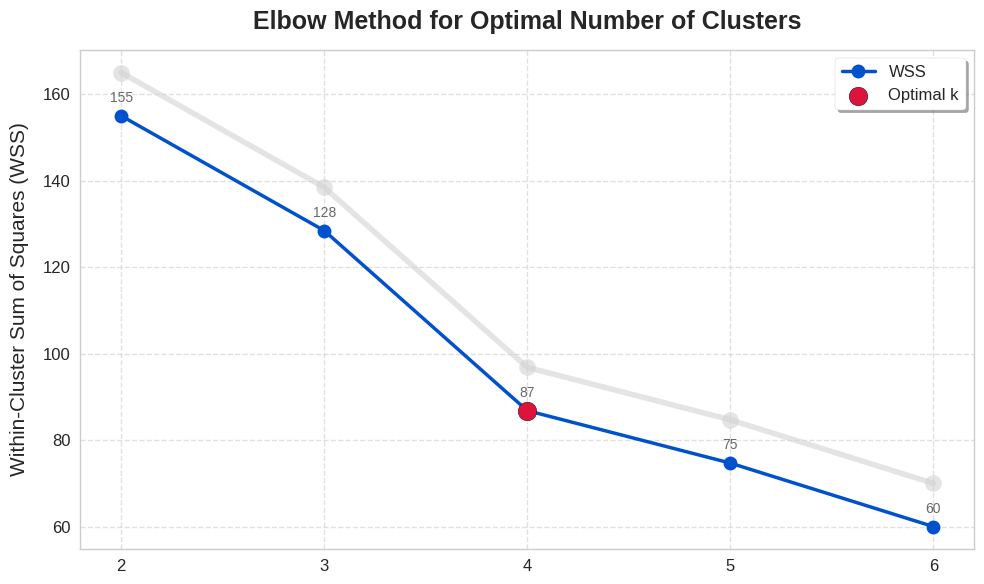

In [59]:
# Visualize the Elbow Method to determine the optimal number of clusters based on WSS values.
# The selected k value is highlighted to show the chosen number of customer segments.

plt.style.use('seaborn-v0_8-whitegrid')

k_opt = 4  

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(cluster_range, [w + 10 for w in wss], 
        marker='o', markersize=12, linewidth=4, color='lightgray', alpha=0.6, zorder=1)

ax.plot(cluster_range, wss, marker='o', markersize=10, linewidth=2.5, color='#0052cc', zorder=2, label='WSS')

ax.scatter(k_opt, wss[cluster_range.index(k_opt)], 
           color='crimson', s=180, edgecolor='black', zorder=3, label='Optimal k')

ax.set_title('Elbow Method for Optimal Number of Clusters', fontsize=18, fontweight='bold', pad=15)
ax.set_ylabel('Within-Cluster Sum of Squares (WSS)', fontsize=15, labelpad=10)

for i, txt in enumerate(wss):
    ax.annotate(f"{txt:.0f}", (cluster_range[i], wss[i]), 
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10, color='dimgray')

ax.set_xticks(cluster_range)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

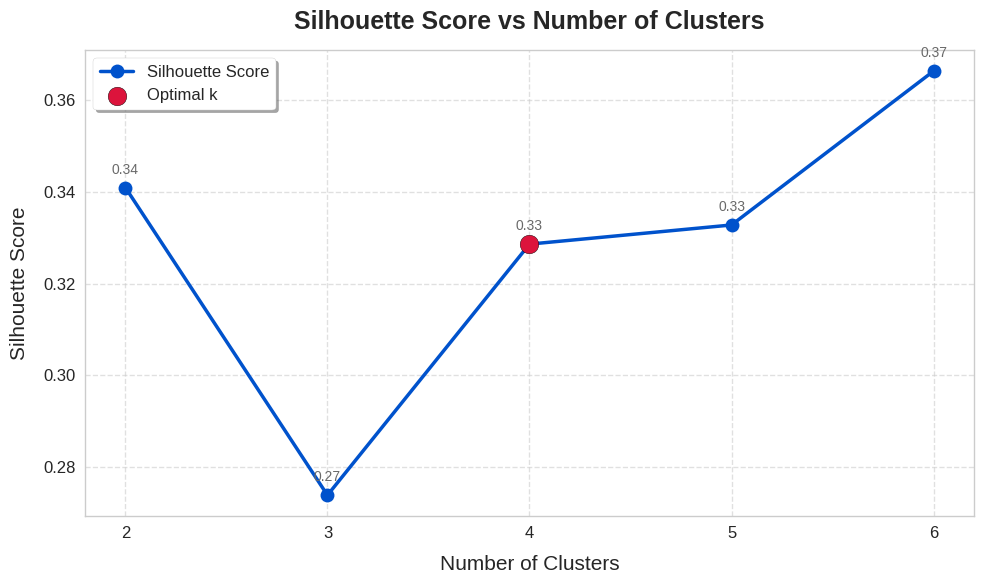

In [60]:
# Visualize silhouette scores for different numbers of clusters to evaluate clustering quality.
# The selected optimal k value is highlighted based on the highest silhouette score.

plt.style.use('seaborn-v0_8-whitegrid')

k_opt = 4

fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(cluster_range, silhouette_scores, marker='o', markersize=10, linewidth=2.5, 
        color='#0052cc', zorder=2, label='Silhouette Score')

ax.scatter(k_opt, silhouette_scores[cluster_range.index(k_opt)],
           color='crimson', s=180, edgecolor='black', zorder=3, label='Optimal k')

ax.set_title('Silhouette Score vs Number of Clusters', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Number of Clusters', fontsize=15, labelpad=10)
ax.set_ylabel('Silhouette Score', fontsize=15, labelpad=10)

for i, txt in enumerate(silhouette_scores):
    ax.annotate(f"{txt:.2f}", (cluster_range[i], silhouette_scores[i]),
                textcoords="offset points", xytext=(0, 10), ha='center',
                fontsize=10, color='dimgray')

ax.set_xticks(cluster_range)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Optimal Number of Clusters Selection</h3>

<p>
The optimal number of customer segments was evaluated using two clustering evaluation 
metrics: <b>Within-Cluster Sum of Squares (WSS)</b> and the <b>Silhouette Score</b>.
</p>

<p>
The Elbow Method based on WSS shows a noticeable improvement up to 
<b>four clusters</b>, after which the reduction in within-cluster variation becomes 
less significant. Additionally, the Silhouette Score indicates that four clusters 
provide a suitable balance between cluster cohesion and separation.
</p>

<p>
Therefore, considering both evaluation metrics, <b>k = 4</b> was selected as the 
optimal number of clusters for customer segmentation. This choice allows the model 
to identify meaningful customer groups while maintaining clear differences between 
segments.
</p>

</div>

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Best Model
</div>

In [61]:
# Initialize the KMeans model
km_model = KMeans(n_clusters=4, init='k-means++', n_init='auto', max_iter=300,
                  tol=0.0001, random_state=880, algorithm='lloyd')

# Fit the model
km_model.fit(X)

# Predict the cluster labels
labels = km_model.predict(X)

# Compute the silhouette score
silhouette_avg = silhouette_score(X, labels)
silhouette = silhouette_samples(X, labels)

print(f'Silhouette Score: {silhouette_avg}')

X_kmeans = X.copy()
X_kmeans['Cluster'] = labels+1
X_kmeans['Silhouette'] = silhouette

X_kmeans.head()

Silhouette Score: 0.3286197358134674


,R_Score,F_Score,M_Score,Cluster,Silhouette
customer_id,,,,,
1026,2,2,3,3,-0.02
1058,1,1,1,1,0.60
1040,3,4,3,3,0.30
1030,1,3,5,2,0.29
1008,2,1,1,1,0.60


In [62]:
# Evaluate the final K-Means clustering model by retrieving the WSS value and cluster centers.
# The WSS value measures the compactness of clusters,
# while cluster centers represent the average profile of each customer segment.

wss = km_model.inertia_
print(f"WSS: {wss:.2f}")

print("-"*80)

centers = km_model.cluster_centers_
print("Cluster Centers:\n", centers)

WSS: 86.88
--------------------------------------------------------------------------------
Cluster Centers:
 [[1.875      1.4375     1.4375    ]
 [2.55555556 3.44444444 5.        ]
 [1.78571429 3.42857143 2.78571429]
 [4.55555556 2.11111111 2.22222222]]


In [63]:
# Suppress warnings
warnings.filterwarnings("ignore")

# Define the score column names

X_kmeans['Cluster'] = X_kmeans['Cluster']
clusters = sorted(X_kmeans['Cluster'].unique())

# Ensure the score columns are of float type
scores = ['R_Score', 'F_Score', 'M_Score']
X_kmeans[scores] = X_kmeans[scores].astype(float)

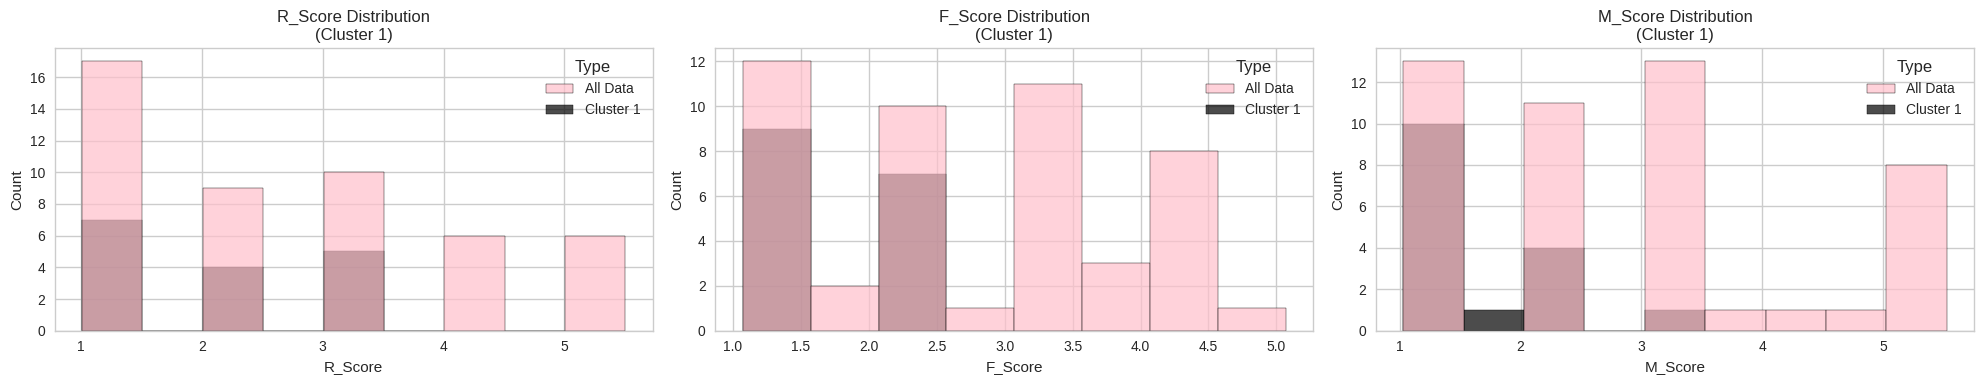

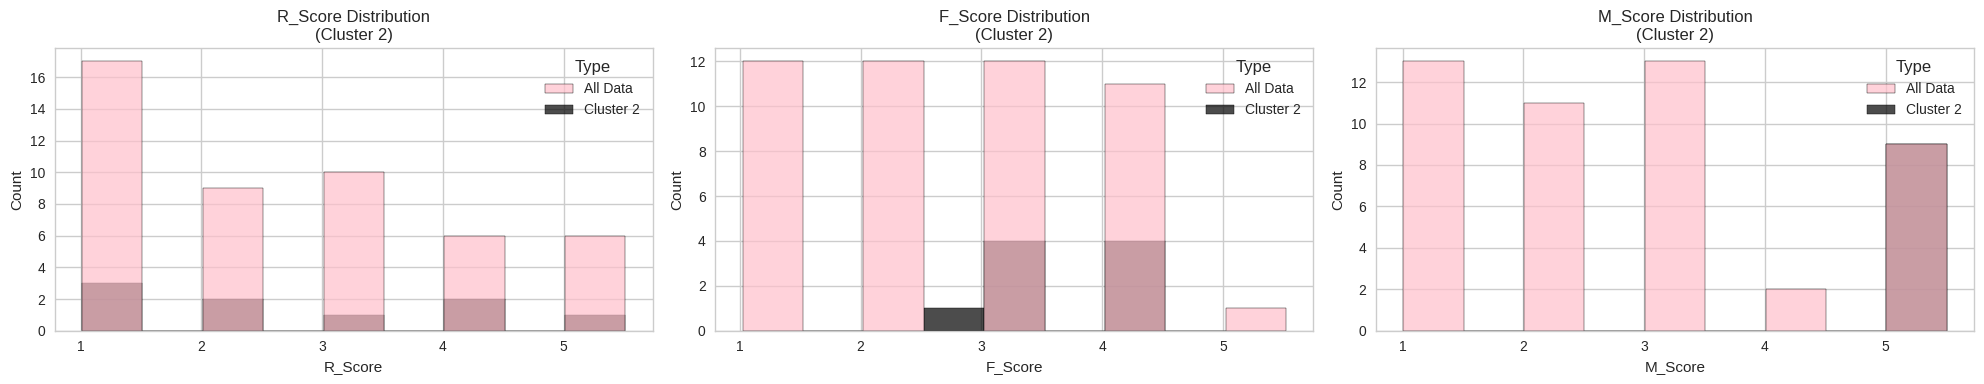

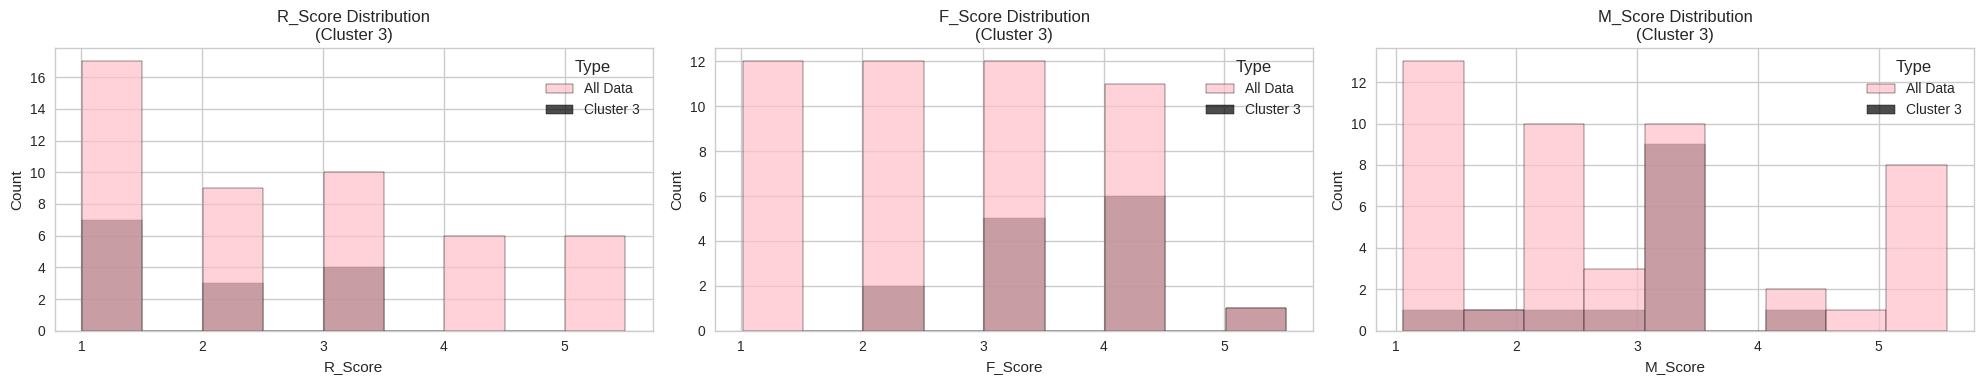

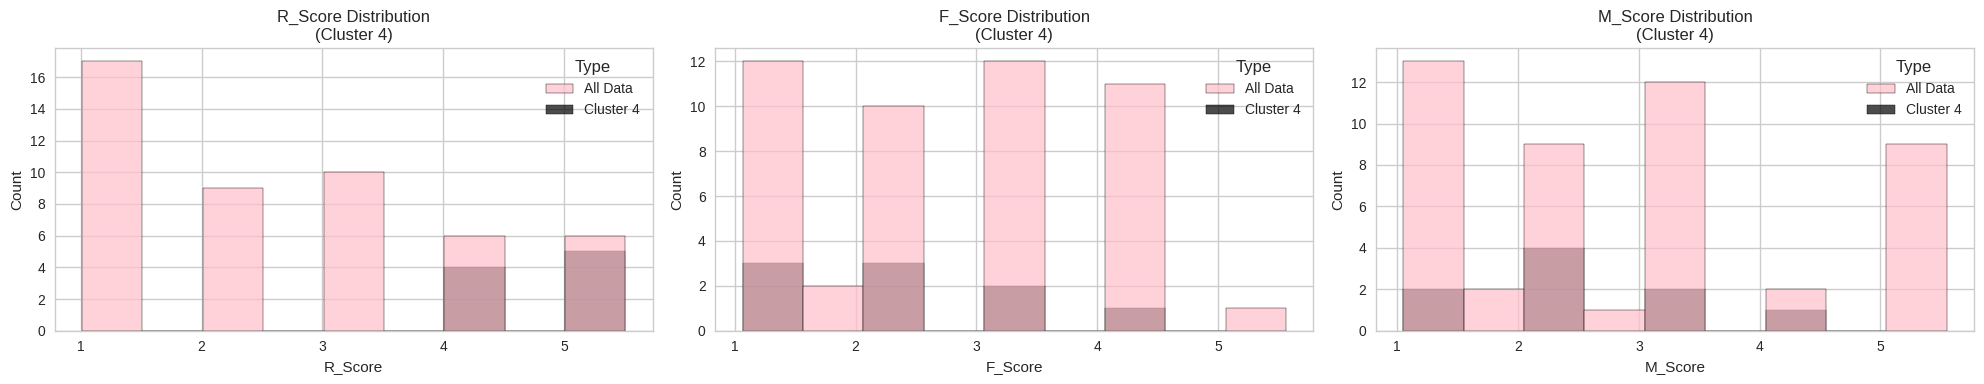

In [64]:
# Loop through each cluster
for cluster in clusters:
    # Create subplots: one for each score
    fig, axes = plt.subplots(1, len(scores), figsize=(20, 4))
    
    for i, score in enumerate(scores):
        ax = axes[i]

        # Create DataFrame for all data and for the specific cluster
        all_data = pd.DataFrame({score: X_kmeans[score], 'Type': 'All Data'})
        data_cluster = pd.DataFrame({
            score: X_kmeans.loc[X_kmeans['Cluster'] == cluster, score],
            'Type': f'Cluster {cluster}'
        })
        # Combine both DataFrames for plotting
        data_combined = pd.concat([all_data, data_cluster])

        # Add half-unit jitter to the score for better visualization
        data_combined[score+'_float'] = data_combined[score] + np.random.uniform(0, 0.5, len(data_combined))

        # Define bins with 0.5 spacing
        bins = np.arange(data_combined[score+'_float'].min(),
                         data_combined[score+'_float'].max() + 0.5,
                         0.5)

        # Plot histogram with hue for cluster vs all data
        sns.histplot(
            x=score+'_float',
            hue='Type',
            data=data_combined,
            ax=ax,
            palette=['pink', 'black'],
            bins=bins,
            stat='count',
            alpha=0.7
        )

        # Set title and axis labels
        ax.set_title(f'{score} Distribution\n(Cluster {cluster})')
        ax.set_xlabel(score)
        ax.set_ylabel('Count')

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

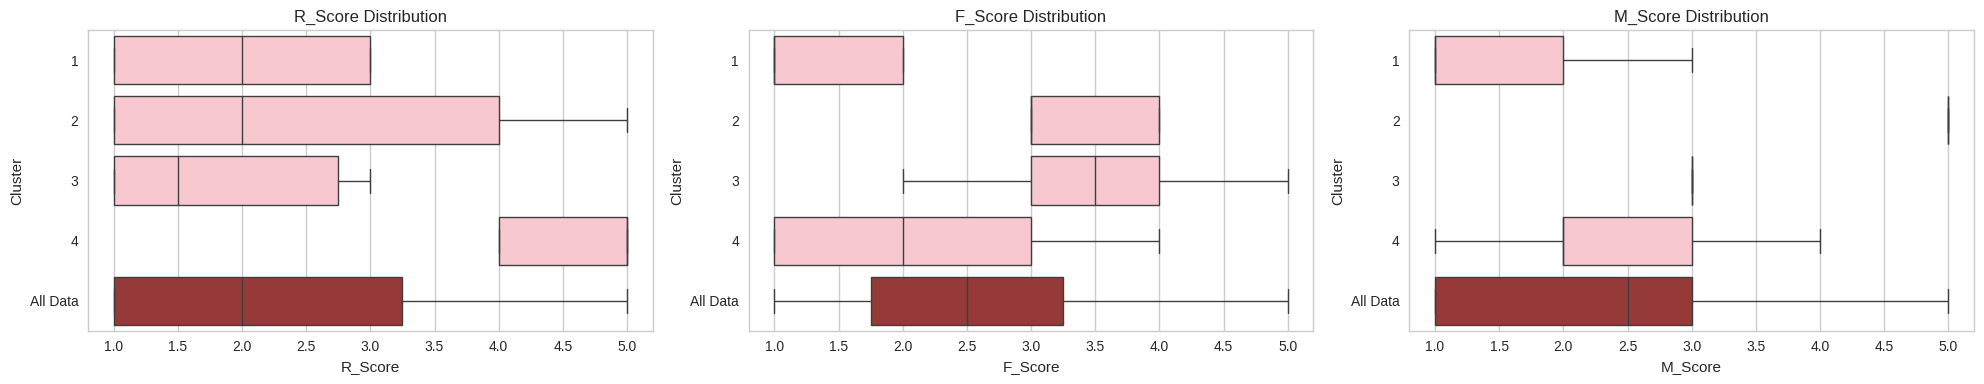

In [65]:
# Set up the matplotlib figure
fig, axes = plt.subplots(1, len(scores), figsize=(20, 4))

# Define the colors
pink_color = 'pink'  
dark_pink_color = 'brown'  

# Loop over each score and create a horizontal box plot
for i, score in enumerate(scores):
    ax = axes[i]    
    
    # Create a DataFrame for all data
    df_all_data = X_kmeans[[score]].copy()
    df_all_data['Cluster'] = 'All Data'

    # Combine the all data DataFrame with the original DataFrame
    combined_df = pd.concat([X_kmeans[['Cluster', score]], df_all_data], ignore_index=True)

    # Sort the clusters including 'All Data'
    combined_df['Cluster'] = pd.Categorical(combined_df['Cluster'], categories= clusters + ['All Data'], ordered=True)

    # Create a horizontal box plot
    sns.boxplot(y='Cluster', x=score, data=combined_df, palette= [pink_color] * len(clusters) + [dark_pink_color], ax=ax, showfliers=False)

    # Set the title and labels
    ax.set_title(f'{score} Distribution')
    ax.set_xlabel(score)
    ax.set_ylabel('Cluster')

plt.tight_layout()
plt.show()

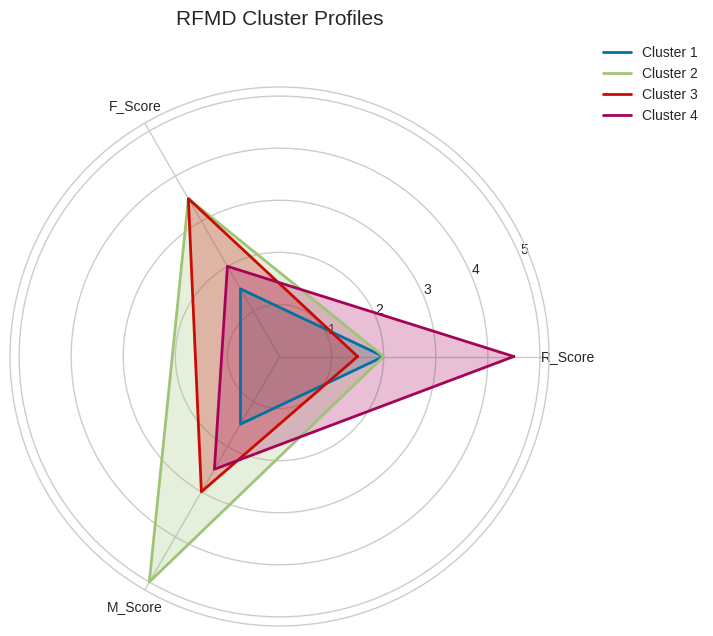

In [67]:
# Visualize customer segment characteristics using a radar chart.
# The chart compares the average Recency, Frequency, and Monetary scores across clusters
# to highlight differences in customer behavior profiles.

radar_data = pd.DataFrame({
    'Cluster': [1, 2, 3, 4],
    'R_Score': [2, 2,1.5, 4.5],     
    'F_Score': [1.5, 3.5, 3.5, 2],      
    'M_Score': [1.5, 5, 3, 2.5],            
})

cluster_profiles = radar_data.groupby('Cluster').mean()

labels = cluster_profiles.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for cluster in cluster_profiles.index:
    values = cluster_profiles.loc[cluster].tolist()
    values += values[:1]  # بستن حلقه
    ax.plot(angles, values, linewidth=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'])
plt.title("RFMD Cluster Profiles", size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Customer Segment Insights</h3>

<p>
The K-Means clustering approach identified four distinct customer segments based on 
their <b>Recency (R)</b>, <b>Frequency (F)</b>, and <b>Monetary (M)</b> behaviors. 
Each segment represents a different level of customer engagement and requires a 
specific business strategy.
</p>

<h4 style="color:#6fa8dc;">Cluster 1: Fresh Customers</h4>

<p>
This segment includes customers with low values across all RFM metrics. These customers 
have recently joined or have limited purchasing activity, resulting in low frequency 
and monetary value. They represent an opportunity for future growth, and targeted 
onboarding campaigns, personalized communication, and incentives for repeat purchases 
can help increase their engagement and lifetime value.
</p>

<h4 style="color:#6fa8dc;">Cluster 2: VIP Customers</h4>

<p>
VIP customers show high purchase frequency and very high monetary value, indicating 
strong loyalty and significant contribution to overall revenue. Although their 
recency is moderate, they remain the most valuable customer group. Retention 
strategies such as loyalty programs, exclusive offers, and personalized services 
should be prioritized to maintain their relationship.
</p>

<h4 style="color:#6fa8dc;">Cluster 3: Engaging Customers</h4>

<p>
This group demonstrates moderate recency with relatively high frequency and monetary 
values. These customers are actively engaged and have the potential to become VIP 
customers in the future. Strengthening their relationship through targeted marketing, 
reward programs, and encouraging higher-value purchases can help move them into the 
VIP segment.
</p>

<h4 style="color:#6fa8dc;">Cluster 4: Churn Customers</h4>

<p>
This segment contains customers with high recency values, meaning they have been 
inactive for a longer period. Their low frequency and moderate monetary value suggest 
a declining relationship with the business. Re-engagement campaigns, personalized 
reminders, and special incentives can be used to recover these customers and prevent 
further churn.
</p>

<p>
Overall, the segmentation provides actionable insights by distinguishing between 
high-value customers, growth opportunities, and customers requiring retention efforts. 
This enables the business to allocate marketing resources more effectively and design 
strategies tailored to each customer group.
</p>

</div>

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Cluster Summary Table
</div>

In [70]:
# ---------------------------
# 1. Calculate cluster means
# ---------------------------
cluster_summary = X_kmeans.groupby('Cluster').mean().reset_index()

# Rename columns for Customer
cluster_summary = X_kmeans.groupby('Cluster')[
    ['R_Score', 'F_Score', 'M_Score']
].mean().reset_index()

# ---------------------------
# 2. Calculate counts and percentages
# ---------------------------
cluster_counts = X_kmeans['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'count']
cluster_counts['percentage'] = (cluster_counts['count'] / len(X_kmeans)) * 100

# Merge counts with summary
cluster_summary = pd.merge(cluster_summary, cluster_counts, on='Cluster')

# ---------------------------
# 3. Calculate overall mean
# ---------------------------
overall_mean = X_kmeans[['R_Score', 'F_Score', 'M_Score']].mean().to_frame().T
overall_mean['Cluster'] = 'All Data'
overall_mean['count'] = len(X_kmeans)
overall_mean['percentage'] = 100.0

# Append overall mean
cluster_summary = pd.concat([cluster_summary, overall_mean], ignore_index=True)

# ---------------------------
# 4. Replace cluster codes with names
# ---------------------------
cluster_name = {
    '3': 'Engaging Customers',
    '4': 'Churn Customers',
    '2': 'VIP Customers',
    '1': 'Fresh Customers'
}

# Only replace numeric clusters
cluster_summary['Cluster'] = cluster_summary['Cluster'].astype(str).replace(cluster_name)

# ---------------------------
# 5. View final summary
# ---------------------------
cluster_summary

,Cluster,R_Score,F_Score,M_Score,count,percentage
0,Fresh Customers,1.88,1.44,1.44,16,33.33
1,VIP Customers,2.56,3.44,5.00,9,18.75
2,Engaging Customers,1.79,3.43,2.79,14,29.17
3,Churn Customers,4.56,2.11,2.22,9,18.75
4,All Data,2.48,2.52,2.65,48,100.00


In [71]:
# Create a binary feature to identify VIP customers based on their assigned cluster.
# Remove clustering-related features after extracting the VIP indicator.
# Merge customer demographic information with the VIP customer label to create the final customer dataset.
# Save the resulting dataset as a CSV file for further analysis or reporting.

X_kmeans['VIP_customer'] = (X_kmeans['Cluster'] == 4).astype(int)
X_kmeans = X_kmeans.drop(columns=['R_Score','F_Score','M_Score','Cluster','Silhouette'])
merged_data = pd.merge(customer_information, X_kmeans, on="customer_id", how="inner")
merged_data.to_csv('Customer.csv')

In [76]:
# Load the final customer dataset

Customer = pd.read_csv("/kaggle/working/Customer.csv")
Customer.set_index('customer_id', inplace=True)
Customer.head()

,gender,age,city,province,signup_date,membership_tier,payment_method,device,returned_items,satisfaction_score,discount_used,VIP_customer
customer_id,,,,,,,,,,,,
1026,M,19.00,Ahvaz,Khuzestan,2022-05-06,Bronze,Card,iPhone,3,4,Yes,0
1058,F,47.00,Tehran,Tehran,2024-09-27,Bronze,Online Wallet,iPhone,0,2,No,0
1040,F,65.00,Tehran,Tehran,2021-11-02,Bronze,Card,Android,3,2,Yes,0
1030,M,60.00,Mashhad,Khorasan,2025-03-07,VIP,Cash,Web,4,4,Yes,0
1008,F,23.00,Rasht,Gilan,2024-10-03,VIP,Online Wallet,iPhone,8,1,No,0


In [77]:
# Convert signup_date to datetime format
Customer['signup_date'] = pd.to_datetime(Customer['signup_date'])

# Extract year and month from signup_date
Customer['signup_year'] = Customer['signup_date'].dt.year
Customer['signup_month'] = Customer['signup_date'].dt.month

# Drop the original date column
Customer.drop(columns=['signup_date'], inplace=True)

Customer.head()

,gender,age,city,province,membership_tier,payment_method,device,returned_items,satisfaction_score,discount_used,VIP_customer,signup_year,signup_month
customer_id,,,,,,,,,,,,,
1026,M,19.00,Ahvaz,Khuzestan,Bronze,Card,iPhone,3,4,Yes,0,2022,5
1058,F,47.00,Tehran,Tehran,Bronze,Online Wallet,iPhone,0,2,No,0,2024,9
1040,F,65.00,Tehran,Tehran,Bronze,Card,Android,3,2,Yes,0,2021,11
1030,M,60.00,Mashhad,Khorasan,VIP,Cash,Web,4,4,Yes,0,2025,3
1008,F,23.00,Rasht,Gilan,VIP,Online Wallet,iPhone,8,1,No,0,2024,10


In [79]:
# Convert the continuous age variable into meaningful age categories for customer profiling.
# Remove the original age column after creating the categorical age feature.

Customer['age_category'] = pd.cut(
    Customer['age'],
    bins=[18, 35, 50, 65],
    labels=['Young Adult', 'Adult', 'Senior']
)

Customer.drop(columns=['age'], inplace=True)

Customer.shape

(48, 13)

<div style="
    background-color:#EAF2F8;
    padding:18px;
    border-radius:10px;
    border-left:8px solid #1F4E79;
    font-family:'Georgia', serif;
    color:#1F4E79;
    font-size:26px;
    font-weight:bold;
    text-align:center;
    letter-spacing:1px;">
    Statistical Analysis
</div>

In [80]:
# Calculate expected frequencies for Chi-square tests between customer attributes and VIP status.
# Check the proportion of cells with low expected counts(<5) to evaluate whether the Chi-square test assumptions are satisfied.
# Store and display expected frequency tables for each categorical feature to support statistical analysis.

expected_values_dict = {}
low_expected_percentage_dict = {}

for col in Customer.columns:
    
    if col == 'VIP_customer':
        continue

    contingency = pd.crosstab(Customer[col], Customer['VIP_customer'])
    _, _, _, exp = chi2_contingency(contingency)

    exp_df = pd.DataFrame(
        exp,
        index=contingency.index,
        columns=contingency.columns
    )
    
    expected_values_dict[col] = exp_df

    percentage_low_expected = (
        (exp < 5).sum().sum() / (exp.shape[0] * exp.shape[1]) * 100
    )

    low_expected_percentage_dict[col] = percentage_low_expected


for col, df_exp in expected_values_dict.items():
    print(f"📊 Expected frequencies for {col}:")
    print(df_exp.round(2))
    print(f"{col}: Percentage of cells with expected counts < 5: {low_expected_percentage_dict[col]:.2f}%")
    print("-" * 60)

📊 Expected frequencies for gender:
VIP_customer     0    1
gender                 
F            21.94 5.06
M            17.06 3.94
gender: Percentage of cells with expected counts < 5: 25.00%
------------------------------------------------------------
📊 Expected frequencies for city:
VIP_customer    0    1
city                  
Ahvaz        4.06 0.94
Isfahan      3.25 0.75
Karaj        4.88 1.12
Mashhad      6.50 1.50
Rasht        3.25 0.75
Shiraz       4.88 1.12
Tabriz       7.31 1.69
Tehran       4.88 1.12
city: Percentage of cells with expected counts < 5: 87.50%
------------------------------------------------------------
📊 Expected frequencies for province:
VIP_customer       0    1
province                 
Alborz          4.88 1.12
East Azerbaijan 7.31 1.69
Fars            4.88 1.12
Gilan           3.25 0.75
Isfahan         3.25 0.75
Khorasan        6.50 1.50
Khuzestan       4.06 0.94
Tehran          4.88 1.12
province: Percentage of cells with expected counts < 5: 87.50%
----

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Chi-Square Test Assumption Evaluation</h3>

<p>
The expected frequency analysis was performed to evaluate whether the categorical 
variables meet the assumptions required for applying the Chi-square test when 
examining their relationship with VIP customer status.
</p>

<p>
The results indicate that <b>gender</b> has the most acceptable expected frequency 
distribution, with only <b>25%</b> of cells having expected counts below 5. This 
suggests that the Chi-square test assumption is relatively better satisfied for this 
feature compared with other variables.
</p>

<p>
However, several features show a high percentage of cells with low expected counts. 
In particular, <b>city</b>, <b>province</b>, and <b>returned_items</b> have more than 
<b>85%</b> of cells below the recommended threshold, while 
<b>signup_month</b> has <b>100%</b> of cells with expected counts below 5. These 
results indicate that these variables contain many categories with limited 
observations, which may reduce the reliability of Chi-square test results.
</p>

<p>
Other variables, including <b>membership tier</b>, <b>payment method</b>, 
<b>device</b>, <b>discount usage</b>, <b>satisfaction score</b>, and 
<b>age category</b>, show moderate violations of the assumption, with around 
<b>50–60%</b> of cells having low expected counts.
</p>

<p>
Overall, the results suggest that the Chi-square findings should be interpreted 
carefully, especially for variables with many categories. Combining rare categories 
or applying alternative statistical approaches could improve the robustness of the 
analysis.
</p>

</div>

In [81]:
# Calculate residuals for each categorical feature to compare observed and expected frequencies.
# Positive residuals indicate that the observed count is higher than expected,
# while negative residuals indicate fewer observations than expected.
# These residuals help identify categories that contribute more strongly to the association with VIP status.

residuals_dict = {}

for col in Customer.columns:
    
    if col == 'VIP_customer':
        continue

    contingency = pd.crosstab(Customer[col], Customer['VIP_customer'])

    _, _, _, exp = chi2_contingency(contingency)

    exp_df = pd.DataFrame(
        exp,
        index=contingency.index,
        columns=contingency.columns
    )

    residuals = contingency - exp_df
    residuals_dict[col] = residuals

    print(f"\nColumn: {col}")
    print("📈 Residuals (Observed - Expected):")
    print(residuals.round(2))
    print("-" * 60)


Column: gender
📈 Residuals (Observed - Expected):
VIP_customer     0     1
gender                  
F             0.06 -0.06
M            -0.06  0.06
------------------------------------------------------------

Column: city
📈 Residuals (Observed - Expected):
VIP_customer     0     1
city                    
Ahvaz        -0.06  0.06
Isfahan      -0.25  0.25
Karaj        -1.88  1.88
Mashhad       1.50 -1.50
Rasht        -0.25  0.25
Shiraz        0.12 -0.12
Tabriz        0.69 -0.69
Tehran        0.12 -0.12
------------------------------------------------------------

Column: province
📈 Residuals (Observed - Expected):
VIP_customer        0     1
province                   
Alborz          -1.88  1.88
East Azerbaijan  0.69 -0.69
Fars             0.12 -0.12
Gilan           -0.25  0.25
Isfahan         -0.25  0.25
Khorasan         1.50 -1.50
Khuzestan       -0.06  0.06
Tehran           0.12 -0.12
------------------------------------------------------------

Column: membership_tier
📈 Residua

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Residual Analysis Insight</h3>

<p>
Residual analysis was performed to identify which customer categories contribute 
more strongly to the differences between observed and expected frequencies in the 
relationship between customer attributes and VIP status.
</p>

<p>
The results show that <b>gender</b> has very small residual values (approximately 
between -0.06 and 0.06), indicating that the distribution of VIP customers across 
genders is very close to what would be expected. Therefore, gender does not appear 
to have a meaningful association with VIP status.
</p>

<p>
Among geographical features, some differences can be observed. For example, 
<b>Karaj</b> shows a higher-than-expected number of VIP customers, while 
<b>Mashhad</b> shows fewer VIP customers than expected. Similarly, 
<b>Alborz province</b> has more VIP customers than expected, whereas 
<b>Khorasan province</b> has fewer than expected. However, these differences should 
be interpreted carefully due to the low expected frequencies in many geographical 
categories.
</p>

<p>
For purchasing behavior variables, <b>payment method</b> shows the strongest pattern. 
Customers using <b>Card payments</b> appear more frequently among VIP customers than 
expected, while <b>Online Wallet</b> users appear less frequently than expected. 
This suggests that payment preferences may have some relationship with customer 
value.
</p>

<p>
The residuals for <b>discount usage</b> indicate that customers who used discounts 
have slightly more VIP customers than expected, while non-discount users have fewer 
VIP customers than expected. However, the differences are relatively small.
</p>

<p>
Regarding satisfaction, customers with a satisfaction score of <b>2</b> appear less 
frequently among VIP customers than expected, while scores of <b>3</b> and <b>5</b> 
show slightly higher VIP representation. These differences suggest that satisfaction 
level alone may not strongly determine VIP status.
</p>

<p>
Overall, the residual analysis suggests that most customer attributes have only 
small deviations from expected VIP distributions. Among the analyzed features, 
<b>payment method</b> and some geographical categories show relatively stronger 
patterns, while variables such as gender show almost no difference. Due to the 
limited sample size and several low expected frequencies, these findings should be 
considered as exploratory rather than definitive evidence of association.
</p>

</div>

In [82]:
def OR_CIs(contingency_table):
    
    # Calculate odds ratio
    odds_ratio = (contingency_table.iloc[0, 0] / contingency_table.iloc[0, 1]) / (contingency_table.iloc[1, 0] / contingency_table.iloc[1, 1])

    # Calculate standard error of log(odds ratio)
    log_odds_std_error = np.sqrt(contingency_table.applymap(lambda x: 1/x).sum().sum())

    # Set confidence level
    confidence_level = 0.95

    # Calculate z-score for the confidence interval
    z_score = norm.ppf(1-(1 - confidence_level) / 2)

    # Calculate confidence intervals
    ci_low = np.exp(np.log(odds_ratio) - z_score * log_odds_std_error)
    ci_high = np.exp(np.log(odds_ratio) + z_score * log_odds_std_error)

    # Print the results
    print(f"Odds Ratio: {odds_ratio:.2f}")
    print(f"95% Confidence Interval: {ci_low:.2f}, {ci_high:.2f}")
    
    return odds_ratio, (ci_low, ci_high)

In [83]:
odds_ratios_dict = {}

for col in Customer.columns:
    if col == 'VIP_customer':
        continue
        
    contingency = pd.crosstab(Customer[col], Customer['VIP_customer'])
    
    if contingency.shape == (2, 2):
        odds_ratio = (contingency.iloc[0, 0] / contingency.iloc[0, 1]) / (contingency.iloc[1, 0] / contingency.iloc[1, 1])
        odds_ratios_dict[col] = odds_ratio
        print(f"nColumn: {col}")
        OR_CIs(contingency)

nColumn: gender
Odds Ratio: 1.04
95% Confidence Interval: 0.24, 4.45
nColumn: discount_used
Odds Ratio: 1.62
95% Confidence Interval: 0.38, 6.96


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Odds Ratio Analysis Insight</h3>

<p>
Odds ratios were calculated to evaluate the strength and direction of the relationship 
between selected customer characteristics and VIP customer status. An odds ratio 
greater than 1 indicates a higher likelihood of being a VIP customer, while a value 
below 1 indicates a lower likelihood compared with the reference group.
</p>

<p>
For <b>gender</b>, the odds ratio is <b>1.04</b>, indicating that the odds of being a 
VIP customer are approximately similar between the two gender groups. However, the 
95% confidence interval (<b>0.24 to 4.45</b>) is wide and includes 1, suggesting that 
there is no statistically clear evidence of a meaningful relationship between gender 
and VIP status.
</p>

<p>
For <b>discount usage</b>, the odds ratio is <b>1.62</b>, suggesting that customers 
who used discounts had approximately <b>62% higher odds</b> of being VIP customers 
compared with customers who did not use discounts. However, the confidence interval 
(<b>0.38 to 6.96</b>) also includes 1, meaning that this relationship is not 
statistically significant and should be interpreted cautiously.
</p>

<p>
Overall, the odds ratio analysis suggests that discount usage may have a positive 
association with VIP status, while gender appears to have little practical impact. 
However, due to the wide confidence intervals, likely caused by the limited sample 
size, these findings should be considered exploratory rather than conclusive.
</p>

</div>

In [84]:
for col in Customer.columns:
    if col == 'VIP_customer':
        continue
        
    contingency = pd.crosstab(Customer[col], Customer['VIP_customer'])
    row_percentages = contingency.div(contingency.sum(axis=1), axis=0) * 100

    chi2, p, dof,_ = chi2_contingency(contingency)
    print(f"\nChi-Square for {col}: p-value={p:.4f}")
    if p > 0.05:
        print(f"👉 {col} is not significantly associated with VIP status.")
    else:
        print(f"👉 {col} is significantly associated with VIP status.")
    
    print("\nContingency Table (Counts):")
    print(contingency)
    print("\nRow Percentages (%):")
    print(row_percentages.round(2))
    print("Degrees of freedom:", dof)
    print("Expected frequencies:\n", exp)
    print("-"*60)


Chi-Square for gender: p-value=1.0000
👉 gender is not significantly associated with VIP status.

Contingency Table (Counts):
VIP_customer   0  1
gender             
F             22  5
M             17  4

Row Percentages (%):
VIP_customer     0     1
gender                  
F            81.48 18.52
M            80.95 19.05
Degrees of freedom: 1
Expected frequencies:
 [[13.8125  3.1875]
 [11.375   2.625 ]
 [13.8125  3.1875]]
------------------------------------------------------------

Chi-Square for city: p-value=0.5073
👉 city is not significantly associated with VIP status.

Contingency Table (Counts):
VIP_customer  0  1
city              
Ahvaz         4  1
Isfahan       3  1
Karaj         3  3
Mashhad       8  0
Rasht         3  1
Shiraz        5  1
Tabriz        8  1
Tehran        5  1

Row Percentages (%):
VIP_customer      0     1
city                     
Ahvaz         80.00 20.00
Isfahan       75.00 25.00
Karaj         50.00 50.00
Mashhad      100.00  0.00
Rasht         75.0

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Chi-Square Test Analysis Insight</h3>

<p>
Chi-square tests were conducted to examine whether customer demographic, behavioral, 
and transactional characteristics are significantly associated with VIP customer 
status.
</p>

<p>
The results indicate that <b>none of the investigated features showed a statistically 
significant association with VIP status</b> at the 5% significance level 
(<i>p-value &gt; 0.05</i>). This suggests that variables such as gender, location, 
membership tier, device type, discount usage, satisfaction score, signup period, 
and age category alone do not provide strong evidence for distinguishing VIP 
customers from other customers.
</p>

<p>
Among the analyzed features, <b>payment method</b> showed the strongest tendency toward 
an association with VIP status, with a p-value of <b>0.0542</b>, which is close to the 
commonly used significance threshold. Customers using <b>Card payments</b> had a higher 
VIP proportion (<b>37.5%</b>) compared with Cash (<b>13.3%</b>) and Online Wallet 
users (<b>5.9%</b>). However, this relationship is not statistically significant and 
requires further investigation with a larger sample size.
</p>

<p>
Some differences were also observed in other variables. For example, customers with 
higher satisfaction scores showed a larger proportion of VIP customers, with 
<b>36.4%</b> of customers with satisfaction score 5 classified as VIP. Similarly, 
discount users had a slightly higher VIP proportion (<b>22.7%</b>) compared with 
non-discount users (<b>15.4%</b>). However, these differences were not strong enough 
to confirm a significant relationship.
</p>

<p>
Overall, the analysis suggests that VIP status is mainly determined by customers' 
purchasing behavior captured through RFM metrics rather than individual demographic 
or categorical characteristics. Therefore, customer segmentation based on 
<b>Recency, Frequency, and Monetary value</b> provides a more effective approach for 
identifying VIP customers than relying on single customer attributes.
</p>

</div>

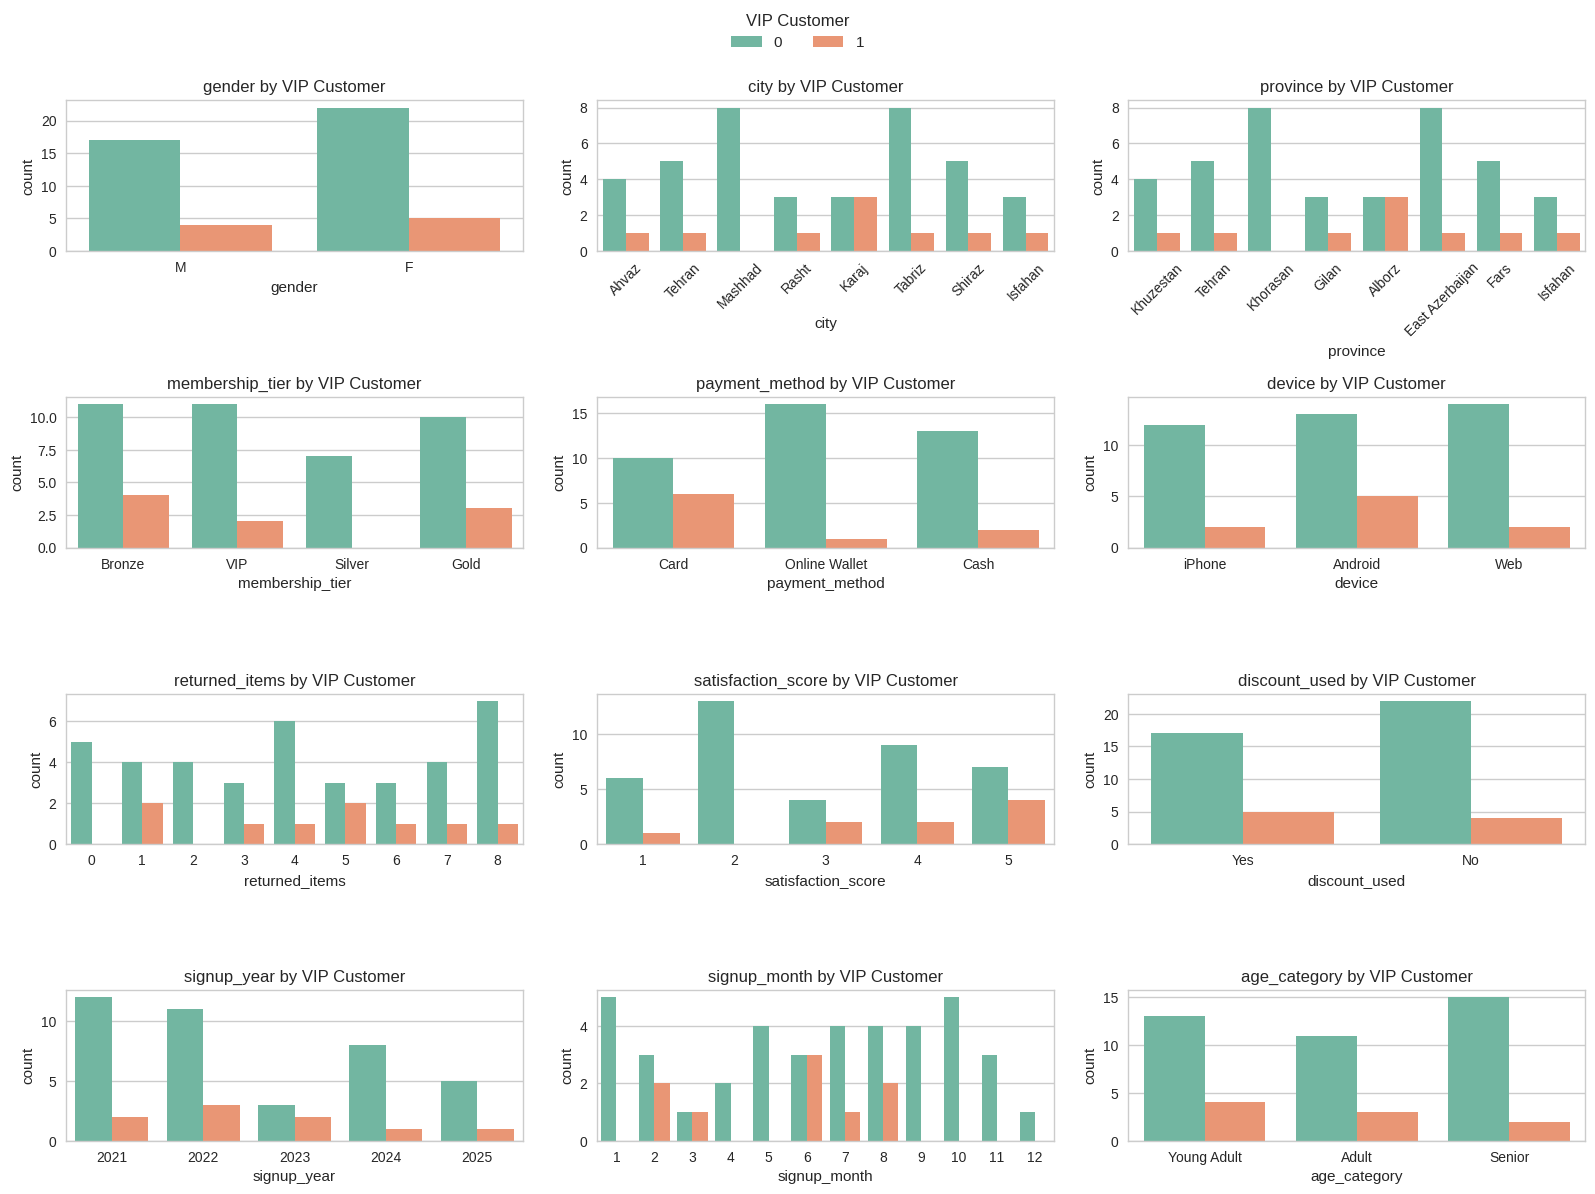

In [138]:
vip_col = "VIP_customer"

fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

plot_index = 0

for col in Customer.columns:
    
    if col == vip_col:
        continue

    ax = axes[plot_index]

    sns.countplot(
        data=Customer,
        x=col,
        hue=vip_col,
        palette="Set2",
        dodge=True,
        ax=ax
    )

    ax.set_title(f"{col} by VIP Customer", fontsize=12)

    # Remove individual legends
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Rotate labels for Province and City
    if col.lower() in ["province", "city"]:
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.tick_params(axis="x", rotation=0)

    plot_index += 1


# Remove unused axes
for ax in axes[plot_index:]:
    fig.delaxes(ax)


# Add one common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="VIP Customer",
    loc="upper center",
    ncol=len(labels),
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [89]:
# Separate input features (X) and target variable (y) for the classification model.

X_Customer = Customer.drop(columns=['VIP_customer'])
y_Customer = Customer['VIP_customer']

In [90]:
# Define categorical feature groups for encoding.
# Apply appropriate encoding methods and combine preprocessing with the Decision Tree model in a pipeline.

ordinal = ['age_category']
nominal = [
    col for col in X_Customer.columns
    if col not in ordinal
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'nominal',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            nominal
        ),
        (
            'ordinal',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            ordinal
        )
    ],
    remainder='passthrough'
)

pipeline = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', DecisionTreeClassifier(
            max_depth=5,
            criterion='entropy',
            class_weight='balanced',
            min_samples_split=8,
            min_samples_leaf=5,
            random_state=880
        ))
    ]
)

In [91]:
# Train the complete pipeline using customer features and VIP status labels.

clf = pipeline.fit(X_Customer, y_Customer)
clf

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'city', 'province',
                                                   'membership_tier',
                                                   'payment_method', 'device',
                                                   'returned_items',
                                                   'satisfaction_score',
                                                   'discount_used',
                                                   'signup_year',
                                                   'signup_month']),
                                                 ('ordinal',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['age_category'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=5, min_samples_split=8,
                                        random_state=880))])

In [92]:
# Visualize the trained Decision Tree with feature names and class labels.
# Display the tree structure to interpret customer classification rules.

fig, ax = plt.subplots(figsize=(30, 25))

clf = pipeline.named_steps['classifier']

plot_tree(
    clf,
    feature_names=pipeline.named_steps['preprocessing'].get_feature_names_out(),
    class_names=[str(c) for c in clf.classes_],
    proportion=True,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

plt.close(fig)

In [93]:
# Transform customer features using the preprocessing pipeline and create an encoded DataFrame.

X_encoded = pd.DataFrame(
    pipeline.named_steps['preprocessing'].transform(X_Customer),
    columns=pipeline.named_steps['preprocessing'].get_feature_names_out(),
    index=X_Customer.index
)

In [94]:
# Extract and display human-readable decision rules from the trained Decision Tree.

tree_rules = export_text(
    pipeline.named_steps['classifier'],
    feature_names=list(pipeline.named_steps['preprocessing'].get_feature_names_out()),
    spacing=3,
    decimals=2,
    show_weights=True
)

print(tree_rules)

|--- nominal__satisfaction_score_2 <= 0.50
|   |--- nominal__province_Khorasan <= 0.50
|   |   |--- nominal__payment_method_Online Wallet <= 0.50
|   |   |   |--- nominal__payment_method_Cash <= 0.50
|   |   |   |   |--- weights: [1.85, 16.00] class: 1
|   |   |   |--- nominal__payment_method_Cash >  0.50
|   |   |   |   |--- nominal__satisfaction_score_5 <= 0.50
|   |   |   |   |   |--- weights: [4.31, 0.00] class: 0
|   |   |   |   |--- nominal__satisfaction_score_5 >  0.50
|   |   |   |   |   |--- weights: [1.85, 5.33] class: 1
|   |   |--- nominal__payment_method_Online Wallet >  0.50
|   |   |   |--- weights: [4.92, 2.67] class: 0
|   |--- nominal__province_Khorasan >  0.50
|   |   |--- weights: [3.08, 0.00] class: 0
|--- nominal__satisfaction_score_2 >  0.50
|   |--- weights: [8.00, 0.00] class: 0



In [95]:
# Define a function to extract decision rules from a trained Decision Tree.
# Traverse the tree structure and store feature-based rules with predicted classes for each leaf node.

def get_decision_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    rules = []
    
    def recurse(node, depth, rule=[]):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            rule_left = rule + [f"{name} <= {threshold:.2f}"]
            recurse(tree_.children_left[node], depth + 1, rule_left)
            rule_right = rule + [f"{name} > {threshold:.2f}"]
            recurse(tree_.children_right[node], depth + 1, rule_right)
        else:
            # Get the predicted class for the leaf node
            predicted_class = np.argmax(tree_.value[node])
            # Append the rule with the consequent
            rules.append((rule, predicted_class))
    
    recurse(0, 1)
    return rules


In [96]:
# Extract feature names from the preprocessing step and generate decision rules from the trained model.

feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

rules = get_decision_rules(clf, feature_names)

In [97]:
# Function to calculate lift, support, and confidence for each rule
def calculate_metrics_for_rule(df, rule, target_column='Target'):
    subset = df.copy()
    for condition in rule:
        if ' <= ' in condition:
            feature, value = condition.split(' <= ')
            subset = subset[subset[feature] <= float(value)]
        elif ' > ' in condition:
            feature, value = condition.split(' > ')
            subset = subset[subset[feature] > float(value)]
    
    support = len(subset) / len(df)
    if len(subset) > 0:
        confidence = len(subset[subset[target_column] == 1]) / len(subset)
    else:
        confidence = 0
    lift = confidence / (len(df[df[target_column] == 1]) / len(df))
    
    return support, confidence, lift

# Create a DataFrame to store rules, metrics, and consequents
rule_metrics = []

# Add the target variable to the encoded DataFrame
X_encoded = pd.DataFrame(X_encoded, columns=feature_names)
X_encoded['Target'] = y_Customer

for rule, consequent in rules:
    support, confidence, lift = calculate_metrics_for_rule(X_encoded, rule)
    rule_metrics.append({
        'Rule': ' AND '.join(rule),
        'Consequent': consequent,  # Add the predicted class as the consequent
        'Support': support,
        'Confidence': confidence,
        'Lift': lift
    })

# Convert the list of dictionaries into a DataFrame
rules_df = pd.DataFrame(rule_metrics)

rules_df = rules_df.reset_index(drop=True)
rules_df.insert(0, 'Row', range(1, len(rules_df) + 1))
rules_df.index = rules_df['Row']
rules_df = rules_df.drop(columns=['Row'])



# Set the maximum column width so that long rules are displayed fully
pd.set_option('display.max_colwidth', None)


rules_df = rules_df.sort_values(by='Lift', ascending=False)

rules_df = rules_df.reset_index(drop=True)
rules_df.index = rules_df.index + 1

rules_df

,Rule,Consequent,Support,Confidence,Lift
1,nominal__satisfaction_score_2 <= 0.50 AND nominal__province_Khorasan <= 0.50 AND nominal__payment_method_Online Wallet <= 0.50 AND nominal__payment_method_Cash <= 0.50,1,0.19,0.67,3.56
2,nominal__satisfaction_score_2 <= 0.50 AND nominal__province_Khorasan <= 0.50 AND nominal__payment_method_Online Wallet <= 0.50 AND nominal__payment_method_Cash > 0.50 AND nominal__satisfaction_score_5 > 0.50,1,0.10,0.40,2.13
3,nominal__satisfaction_score_2 <= 0.50 AND nominal__province_Khorasan <= 0.50 AND nominal__payment_method_Online Wallet > 0.50,0,0.19,0.11,0.59
4,nominal__satisfaction_score_2 <= 0.50 AND nominal__province_Khorasan <= 0.50 AND nominal__payment_method_Online Wallet <= 0.50 AND nominal__payment_method_Cash > 0.50 AND nominal__satisfaction_score_5 <= 0.50,0,0.15,0.00,0.00
5,nominal__satisfaction_score_2 <= 0.50 AND nominal__province_Khorasan > 0.50,0,0.10,0.00,0.00
6,nominal__satisfaction_score_2 > 0.50,0,0.27,0.00,0.00


<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">Decision Tree Rule Analysis Insight</h3>

<p style="line-height:1.6; text-align:justify;">
The Decision Tree model was used to identify customer characteristics and behavioral 
patterns associated with VIP customer status. The extracted rules provide 
interpretable conditions that explain how the model distinguishes VIP and non-VIP 
customers.
</p>

<ul style="padding-left:25px;">

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Main VIP Pattern:</b> Customers with a satisfaction score different from 2, living 
outside Khorasan province, and not using Online Wallet or Cash payment methods are 
more likely to be classified as VIP customers. This rule achieved <b>67% confidence</b>, 
meaning that two-thirds of customers following this pattern belong to the VIP group. 
The <b>lift value of 3.56</b> indicates that these customers are more than three times 
more likely to be VIP compared with the overall customer population.
</p>
</li>

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Additional VIP Pattern:</b> Customers with a high satisfaction score (score 5), 
using Cash payments, and living outside Khorasan province showed a higher probability 
of being VIP customers. However, this rule has lower predictive strength with 
<b>40% confidence</b>.
</p>
</li>

<li style="margin-bottom:20px;">
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Non-VIP Pattern:</b> Customers using Online Wallet payments under certain conditions 
were less likely to belong to the VIP group. The lift value below 1 (<b>0.59</b>) 
indicates that this group has a lower VIP representation compared with the average 
customer population.
</p>
</li>

<li>
<p style="line-height:1.7; text-align:justify; margin:0;">
<b>Business Interpretation:</b> The model suggests that <b>satisfaction level, payment 
method, and location</b> are the main factors contributing to VIP customer 
classification. However, because of the limited dataset size, these rules should be 
considered exploratory insights rather than definitive customer behavior patterns.
</p>
</li>

</ul>

</div>

<div style="background-color:#1e1e1e; padding:15px; border-left:5px solid #4a90e2; border-radius:8px; color:#f0f0f0; font-family:'Times New Roman', serif;">

<h3 style="color:#7db7ff;">💡 Business Recommendations</h3>

<p>
The analysis indicates that <b>VIP customers are mainly associated with higher satisfaction levels, 
card-based payments, and customers located outside Khorasan province</b>. These characteristics provide 
valuable insights into the behaviors and preferences of the company's most valuable customers.
</p>

<p>
Customers who demonstrate higher satisfaction and stronger engagement are more likely to contribute 
significantly to business revenue. Therefore, understanding these patterns can help the company identify 
potential high-value customers and design more effective marketing strategies.
</p>

<p>
To increase the number of VIP customers, the company should focus on improving customer satisfaction, 
providing a smoother purchasing experience, encouraging preferred payment behaviors, and developing 
personalized loyalty programs. These actions can strengthen customer relationships, increase retention, 
and support long-term revenue growth.
</p>

</div>